# [과제 1] 빈칸 채우기

출처 : https://github.com/teddylee777/machine-learning/blob/master/07-Scikit-Learn/tutorial/09-%EC%95%99%EC%83%81%EB%B8%94-(Ensemble)-(%EC%8B%A4%EC%8A%B5).ipynb

**참고자료 (블로그)**

* [보팅(Voting)](https://teddylee777.github.io/machine-learning/ensemble%EA%B8%B0%EB%B2%95%EC%97%90-%EB%8C%80%ED%95%9C-%EC%9D%B4%ED%95%B4%EC%99%80-%EC%A2%85%EB%A5%98-1)
* [배깅(Bagging)](https://teddylee777.github.io/machine-learning/ensemble%EA%B8%B0%EB%B2%95%EC%97%90-%EB%8C%80%ED%95%9C-%EC%9D%B4%ED%95%B4%EC%99%80-%EC%A2%85%EB%A5%98-2)
* [부스팅(Boosting)](https://teddylee777.github.io/machine-learning/ensemble%EA%B8%B0%EB%B2%95%EC%97%90-%EB%8C%80%ED%95%9C-%EC%9D%B4%ED%95%B4%EC%99%80-%EC%A2%85%EB%A5%98-3)

### 모델별 성능평가를 위한 함수

- 시작하기에 앞서, 과제로 사용한 자료 원본 제작자인 Teddynote 님의 커스텀 모듈을 다운받아보겠습니다.

In [1]:
# 모듈 설치 (조금 오래 걸릴 수 있어요~)
!pip install teddynote -q

In [2]:
from teddynote import utils

utils.set_plot_options(figsize=(12, 10)) # 그래프 사이즈 설정
utils.set_plot_error('mse') # MSE 에러 설정

### 필요한 데이터셋 로드

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
import warnings

warnings.filterwarnings('ignore')  # 경고 메시지 숨기기
np.set_printoptions(suppress=True, precision=3)

In [4]:
# California Housing 데이터셋 로드
# 캘리포니아 지역별 주택 가격을 예측하는 문제
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X, y = housing.data, housing.target

In [5]:
X = pd.DataFrame(X, columns=housing.feature_names)
y = pd.DataFrame(y, columns=['target'])

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**컬럼 소개**

속성 수 : 8

* **MedInc** : 해당 지역의 중위 가구 소득 (단위: 10,000달러) / 예: 3.5 → $35,000
* **HouseAge** : 해당 지역의 주택 평균 연식
* **AveRooms** : 세대당 평균 방 개수
* **AveBedrms** : 세대당 평균 침실 개수
* **Population** : 해당 지역의 총 인구 수
* **AveOccup** : 세대당 평균 거주 인원 수
* **Latitude** : 위도 (지리적 위치)
* **Longitude** : 경도 (지리적 위치)

목표 변수
* **target** : 해당 지역의 중위 주택 가격 (단위: 100,000달러) / 예: 2.5 → $250,000

### 간단한 전처리

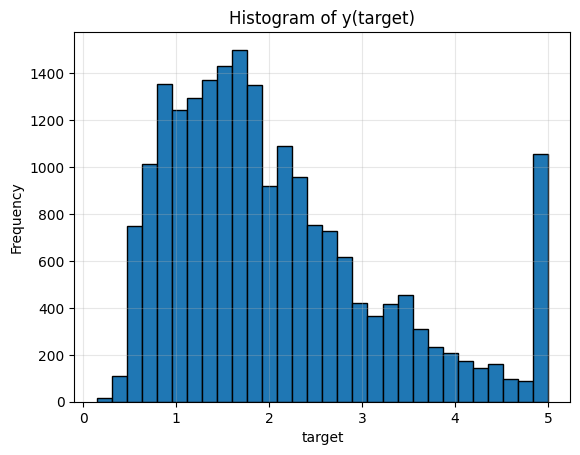

In [6]:
# 타겟변수(y)의 분포

plt.hist(y, bins=30, edgecolor='black')
plt.title("Histogram of y(target)")
plt.xlabel("target")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# target의 최댓값(5.0)이 유독 많이 등장함 → 데이터 수집 당시 상한선이 존재했던 것으로 추정
print(f"최댓값: {np.max(y)}, 개수: {y[y['target'] == np.max(y)].count()}")

최댓값: 5.00001, 개수: target    965
dtype: int64


In [8]:
# target == 5.0인 행은 실제 가격이 아닌 캡핑된 값일 가능성이 높으므로 제외하겠습니다.
# reset_index(drop=True): 행 삭제 후 인덱스를 0부터 재정렬
X = X[y['target'] <= 5].reset_index(drop=True)
y = y[y['target'] <= 5].reset_index(drop=True)

**데이터 분할**

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# shape 확인
print(X_train.shape, X_test.shape)

(15740, 8) (3935, 8)


## 단일 회귀 모델

앙상블 모델과 성능을 비교하기 위해 먼저 단일 회귀 모델들을 학습합니다.

| 모델 | 특징 |
|------|------|
| LinearRegression | 규제 없는 기본 선형 회귀 |
| Ridge | L2 규제 (계수 크기를 전반적으로 줄임) |
| Lasso | L1 규제 (불필요한 피처 계수를 0으로 만들어 선택 효과) |
| ElasticNet | L1 + L2 혼합 규제 |


In [13]:
from sklearn.linear_model import LinearRegression # 선형회귀
from sklearn.linear_model import Ridge # 릿지 (L2 규제)
from sklearn.linear_model import Lasso # 라쏘 (L1 규제)
from sklearn.linear_model import ElasticNet # 엘라스틱넷
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder # 스케일러, 인코더
from sklearn.pipeline import make_pipeline # 파이프라인
from sklearn.preprocessing import PolynomialFeatures # 다항회귀
from sklearn.metrics import r2_score, mean_squared_error # 성능평가지표

### LinearRegression

In [14]:
# 모델 정의
lr = LinearRegression()

# 모델 학습
lr.fit(X_train, y_train)

# 예측
lr_pred = lr.predict(X_test)

# 성능 평가
lr_r2 = r2_score(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)

print(f'R2 : {round(lr_r2, 4)}, MSE : {round(lr_mse, 4)}')

R2 : 0.5749, MSE : 0.4239


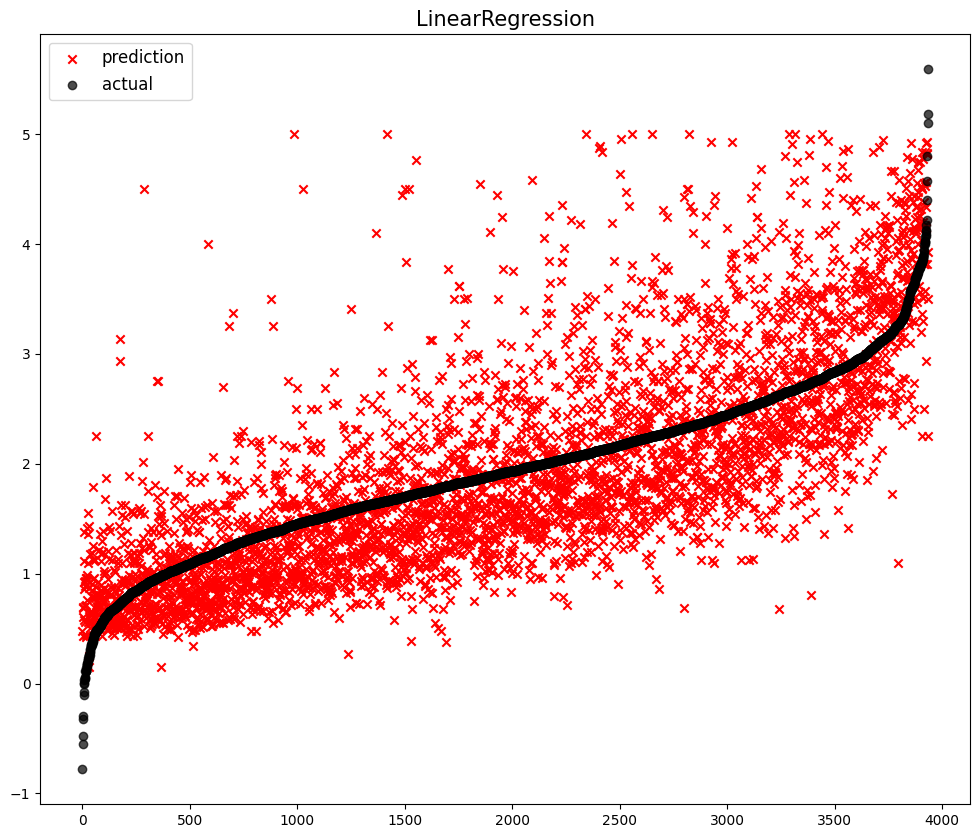

,model,error
0,LinearRegression,0.423897


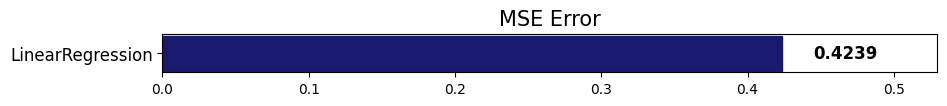

In [15]:
# 이 코드를 돌리면 예측 결과 시각화 및 각 모델의 성능이 계속 업데이트가 됩니다.
utils.plot_error('LinearRegression', lr_pred, y_test)

### Ridge

> **L2 규제**: 모든 계수를 골고루 작게 만들어 과대적합을 방지합니다.  
> `alpha`가 클수록 규제가 강해져 계수가 더 작아집니다.


In [17]:
# 모델 정의 (규제 계수인 alpha는 0.1로 적용합니다.)
ridge = Ridge(alpha=0.1)

# 모델 학습
ridge.fit(X_train, y_train)

# 예측
ridge_pred = ridge.predict(X_test)

# 성능 평가
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)

print(f'R2 : {round(ridge_r2, 4)}, MSE : {round(ridge_mse, 4)}')

R2 : 0.5749, MSE : 0.4239


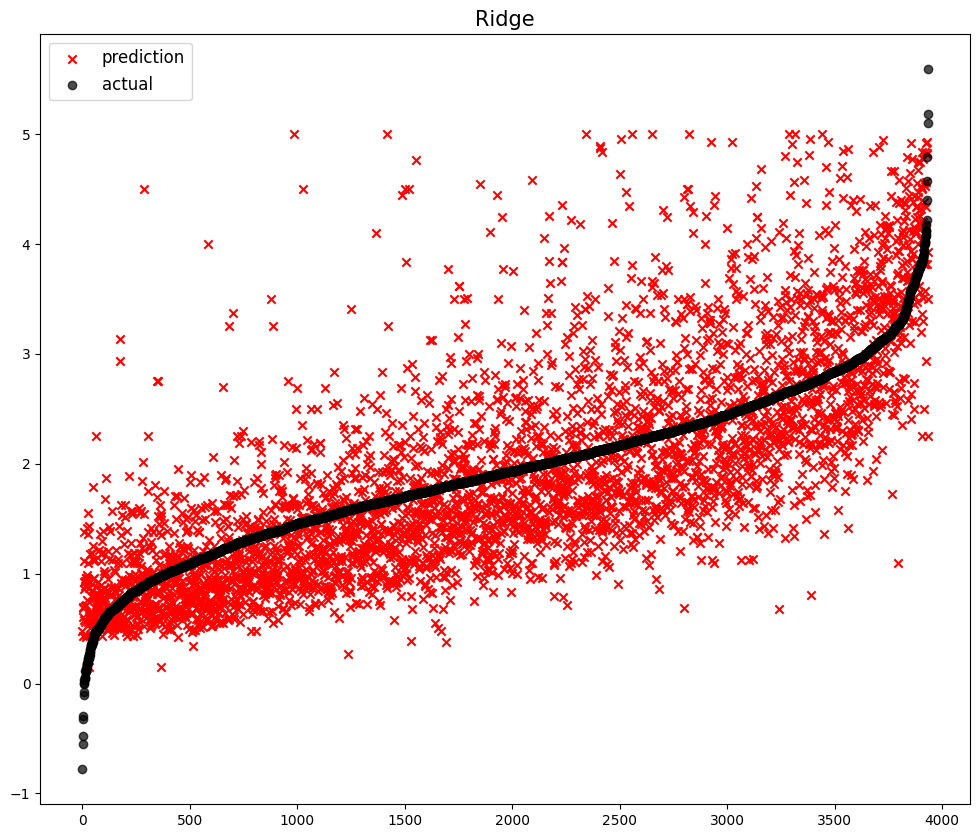

,model,error
0,Ridge,0.423898
1,LinearRegression,0.423897


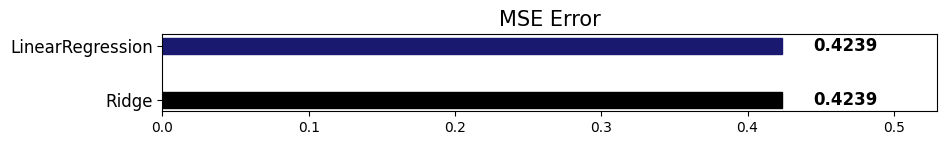

In [18]:
utils.plot_error('Ridge', ridge_pred, y_test)

### Lasso

> **L1 규제**: 불필요한 피처의 계수를 정확히 0으로 만들어 자동으로 피처를 선택하는 효과가 있습니다.  
> Ridge보다 작은 `alpha`를 쓰는 경우가 많습니다.


In [19]:
# 모델 정의 (규제 계수인 alpha는 0.01로 적용합니다.)
lasso = Lasso(alpha=0.01)

# 모델 학습
lasso.fit(X_train, y_train)

# 예측
lasso_pred = lasso.predict(X_test)

# 성능 평가
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print(f'R2 : {round(lasso_r2, 4)}, MSE : {round(lasso_mse, 4)}')

R2 : 0.5645, MSE : 0.4342


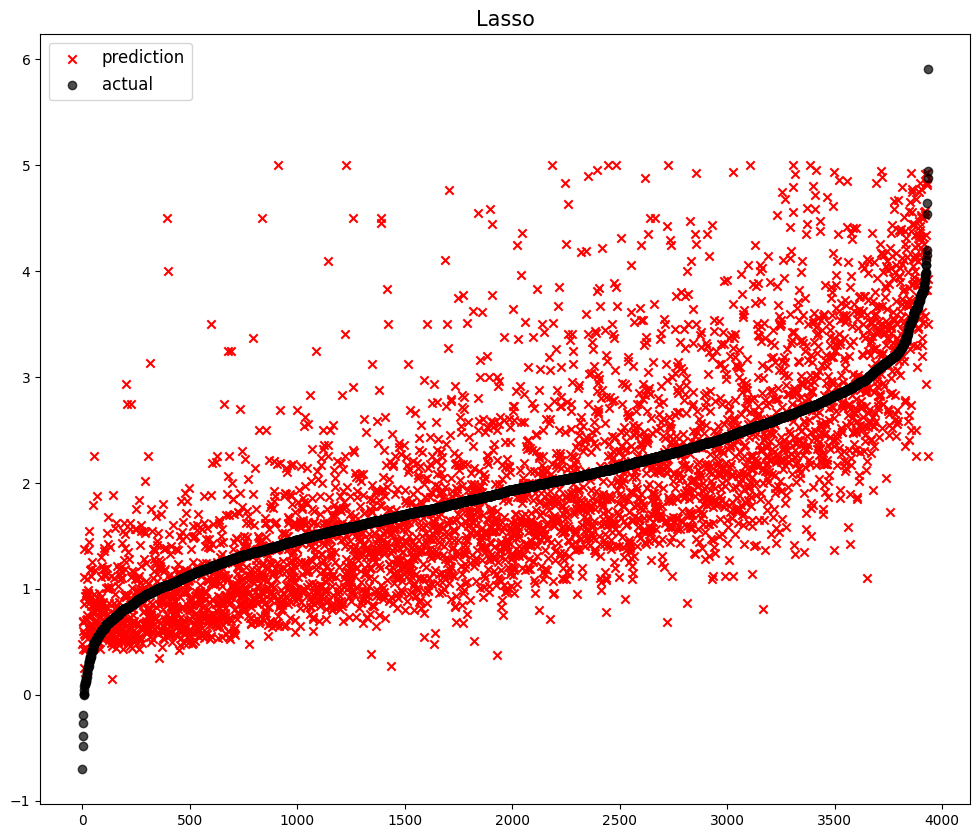

,model,error
0,Lasso,0.434209
1,Ridge,0.423898
2,LinearRegression,0.423897


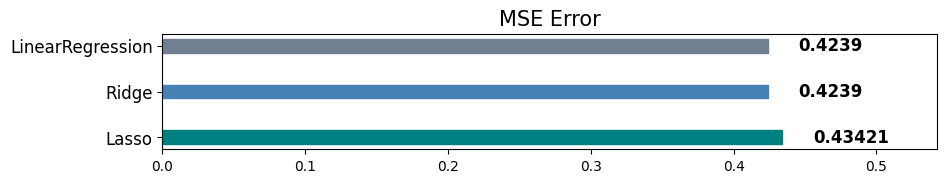

In [20]:
utils.plot_error('Lasso', lasso_pred, y_test)

### ElasticNet

> **L1 + L2 혼합 규제**: `l1_ratio`로 L1과 L2의 비율을 조절합니다.  
> `l1_ratio=1`이면 Lasso, `l1_ratio=0`이면 Ridge와 동일합니다.


In [21]:
# 모델 정의 (규제 계수 `alpha=0.001`, `l1_ratio=0.8` 로 적용합니다.)
elasticnet = ElasticNet(alpha=0.001, l1_ratio=0.8)

# 모델 학습
elasticnet.fit(X_train, y_train)

# 예측
elasticnet_pred = elasticnet.predict(X_test)

# 성능 평가
elasticnet_r2 = r2_score(y_test, elasticnet_pred)
elasticnet_mse = mean_squared_error(y_test, elasticnet_pred)

print(f'R2 : {round(elasticnet_r2, 4)}, MSE : {round(elasticnet_mse, 4)}')

R2 : 0.5744, MSE : 0.4244


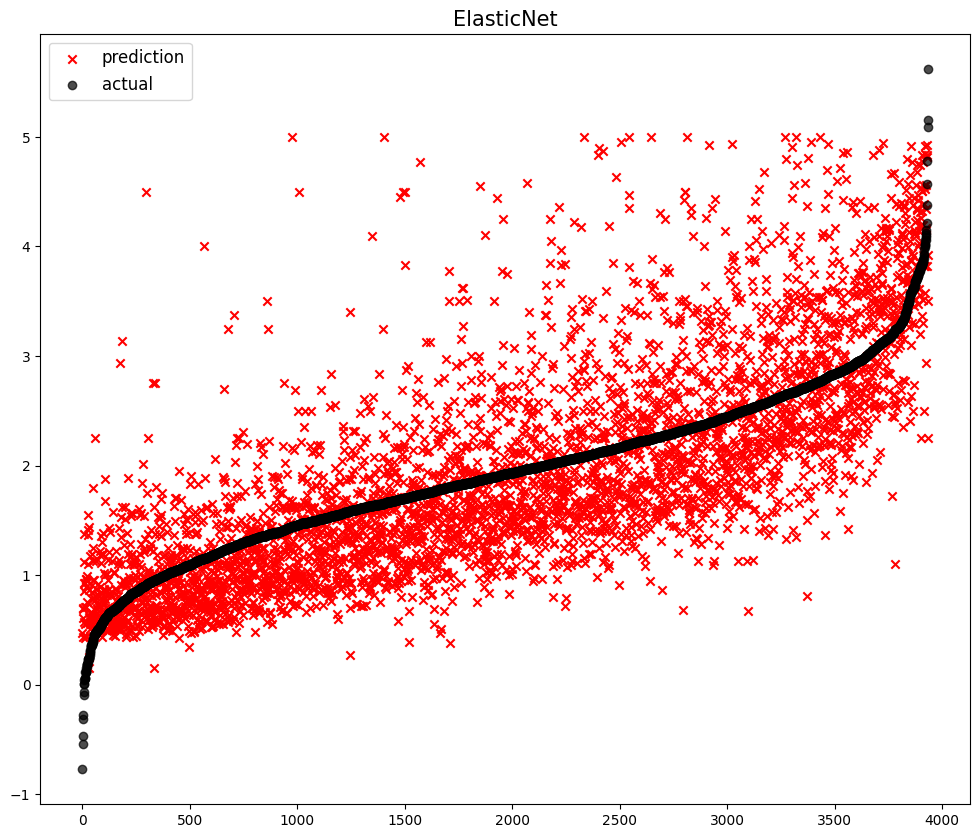

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Ridge,0.423898
3,LinearRegression,0.423897


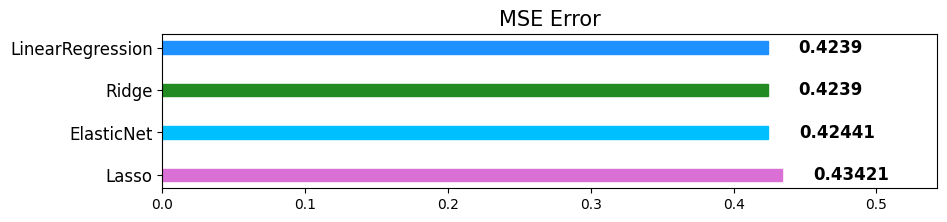

In [22]:
utils.plot_error('ElasticNet', elasticnet_pred, y_test)

### Pipeline 학습

**파이프라인(Pipeline)** 은 전처리 → 모델 학습을 하나의 흐름으로 연결해주는 도구입니다.

**왜 파이프라인을 써야 할까요?**

스케일링을 학습/테스트에 따로 적용하면 **데이터 누수(data leakage)** 가 발생할 수 있습니다.  
파이프라인을 쓰면 `fit()` 시 학습 데이터 기준으로만 스케일러가 맞춰지고, `predict()` 시엔 그 기준이 자동 적용되어 누수를 방지합니다.

먼저 `StandardScaler → ElasticNet` 파이프라인을 구성해 봅시다.

In [23]:
# 파이프라인 정의 (규제 계수 `alpha=0.001`, `l1_ratio=0.8`을 적용합니다.)
standard_elasticnet = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.001, l1_ratio=0.8)
)

# 파이프라인 학습
standard_elasticnet.fit(X_train, y_train)

# 예측
standard_elasticnet_pred = standard_elasticnet.predict(X_test)

# 성능 평가
standard_elasticnet_r2 = r2_score(y_test, standard_elasticnet_pred)
standard_elasticnet_mse = mean_squared_error(y_test, standard_elasticnet_pred)

print(f'R2 : {round(standard_elasticnet_r2, 4)}, MSE : {round(standard_elasticnet_mse, 4)}')

R2 : 0.5744, MSE : 0.4244


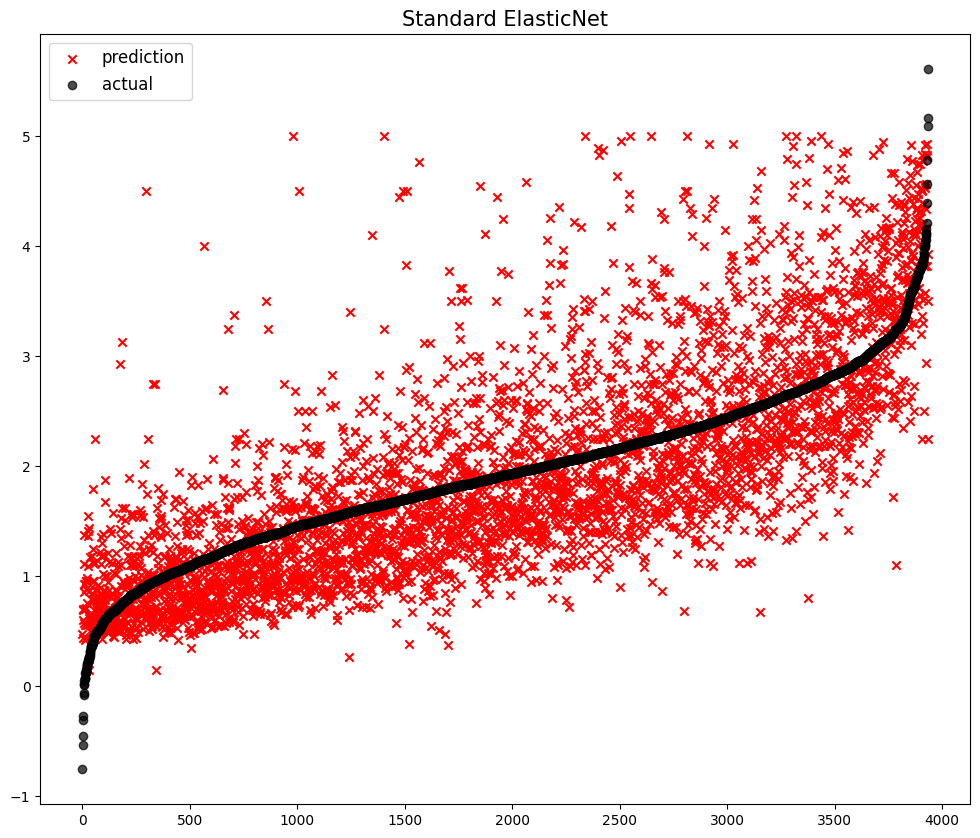

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897


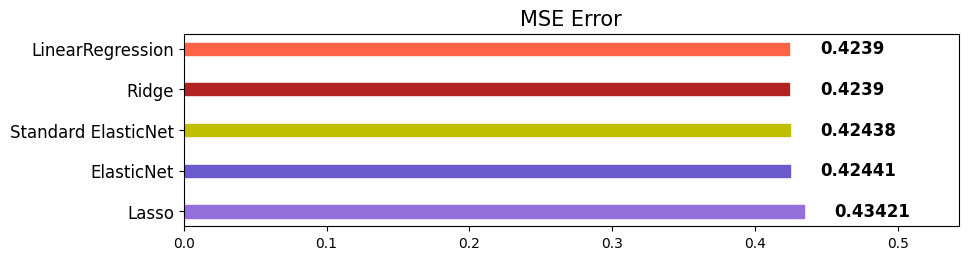

In [24]:
utils.plot_error('Standard ElasticNet', standard_elasticnet_pred, y_test)

### PolynomialFeatures

PolynomialFeatures는 다항식 회귀모델을 위해 기존 변수들을 다항식으로 만들 때 사용했습니다. 기억나시나요?   

PolynomialFeatures는 기존 피처들의 다항 조합을 새로운 피처로 만들어 **비선형 관계**를 선형 모델로 학습할 수 있게 합니다.

- `degree=2`: 원본 피처 간의 제곱 및 교호작용 항 생성 (피처 수가 크게 늘어남)
- `include_bias=False`: 상수항(1) 컬럼은 제외

이번에는 `PolynomialFeatures → StandardScaler → ElasticNet` 파이프라인을 구성해 봅시다.

In [25]:
# 파이프라인 정의
# (PolynomialFeatures는 `degree=2`, `include_bias=False`를 적용합니다.)
# (ElasticNet 모델은 규제 계수 `alpha=0.001`, `l1_ratio=0.8 을 적용합니다.)
poly_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    ElasticNet(alpha=0.001, l1_ratio=0.8)
)

# 모델 학습
poly_pipeline.fit(X_train, y_train)

# 예측
poly_pipeline_pred = poly_pipeline.predict(X_test)

# 성능 평가
poly_pipeline_r2 = r2_score(y_test, poly_pipeline_pred)
poly_pipeline_mse = mean_squared_error(y_test, poly_pipeline_pred)

print(f'R2 : {round(poly_pipeline_r2, 4)}, MSE : {round(poly_pipeline_mse, 4)}')

R2 : 0.6074, MSE : 0.3915


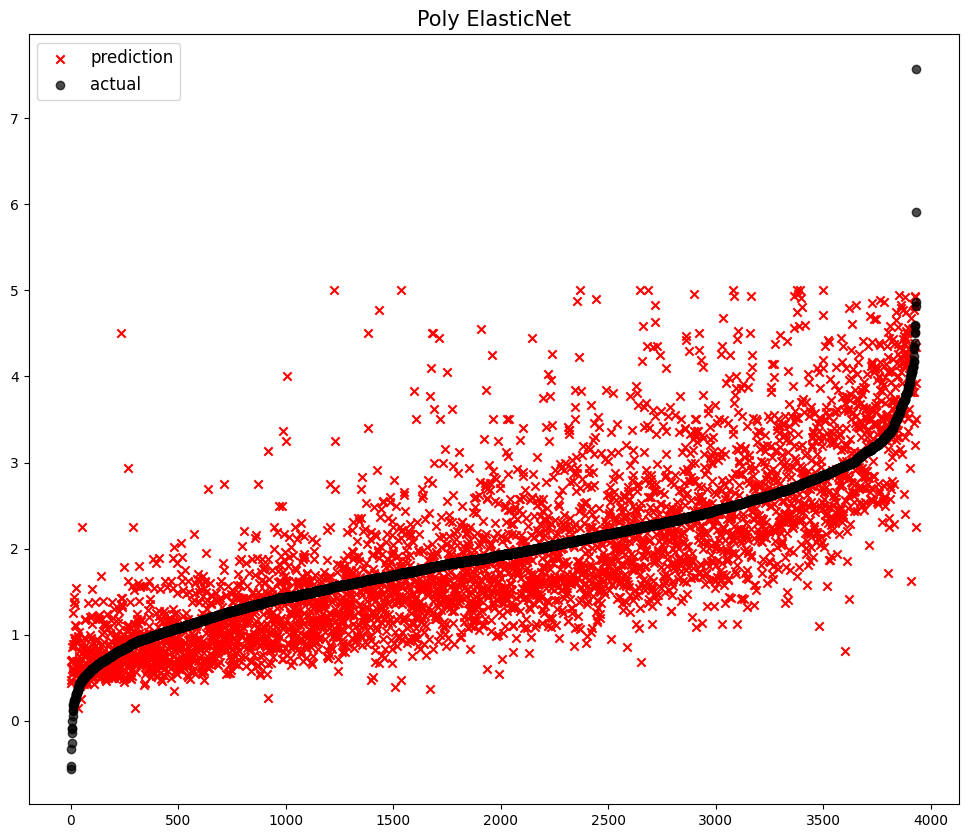

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Poly ElasticNet,0.391494


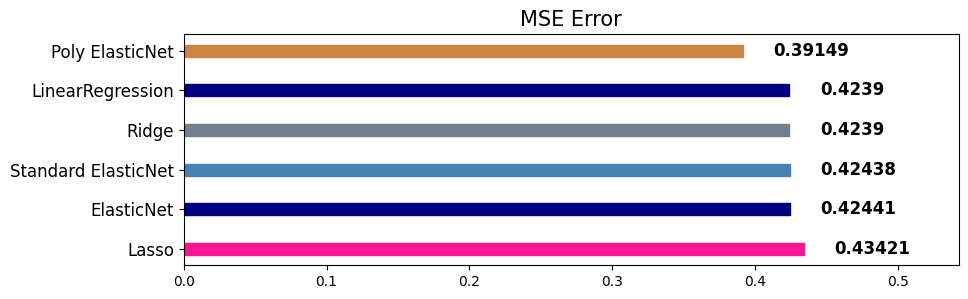

In [26]:
utils.plot_error('Poly ElasticNet', poly_pipeline_pred, y_test)

## 앙상블 모델

### 보팅 (Voting) - 회귀 (Regression)

Voting은 **서로 다른 알고리즘** 모델들의 예측을 투표를 통해 결합하는 방식입니다.  
Voting은 Bagging과 투표방식이라는 점에서 유사하지만, 다음과 같은 큰 차이점이 있습니다.  

- **Voting (회귀)**: 각 모델의 예측값을 **평균**내어 최종 예측
- **Bagging**: 같은 알고리즘 내에서 다른 샘플 조합으로 앙상블

아래에서는 앞서 학습한 선형 모델 5개를 묶어 VotingRegressor를 구성합니다.


In [29]:
from sklearn.ensemble import VotingRegressor, VotingClassifier

`VotingRegressor`의 `estimators` 인자는 반드시 **`(이름, 모델)` 튜플 리스트** 형태로 전달해야 합니다.  
이름은 내부 식별자로 사용되며, 중복되면 안 됩니다.


In [30]:
# 앞서 학습한 단일 모델들을 (이름, 모델) 튜플 형태로 묶음
single_models = [
    ('lr', lr),
    ('ridge', ridge),
    ('lasso', lasso),
    ('standard_elasticnet', standard_elasticnet),
    ('poly_pipeline', poly_pipeline)
]

In [31]:
voting_regressor = VotingRegressor(estimators=single_models)

In [32]:
voting_regressor.fit(X_train, y_train) # 신기하죠?

,estimators,"[('lr', ...), ('ridge', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,alpha,0.1
,fit_intercept,True


In [33]:
voting_pred = voting_regressor.predict(X_test)

In [34]:
# 성능 평가
voting_r2 = r2_score(y_test, voting_pred)
voting_mse = mean_squared_error(y_test, voting_pred)

print(f'R2 : {round(voting_r2, 4)}, MSE : {round(voting_mse, 4)}')

R2 : 0.5835, MSE : 0.4153


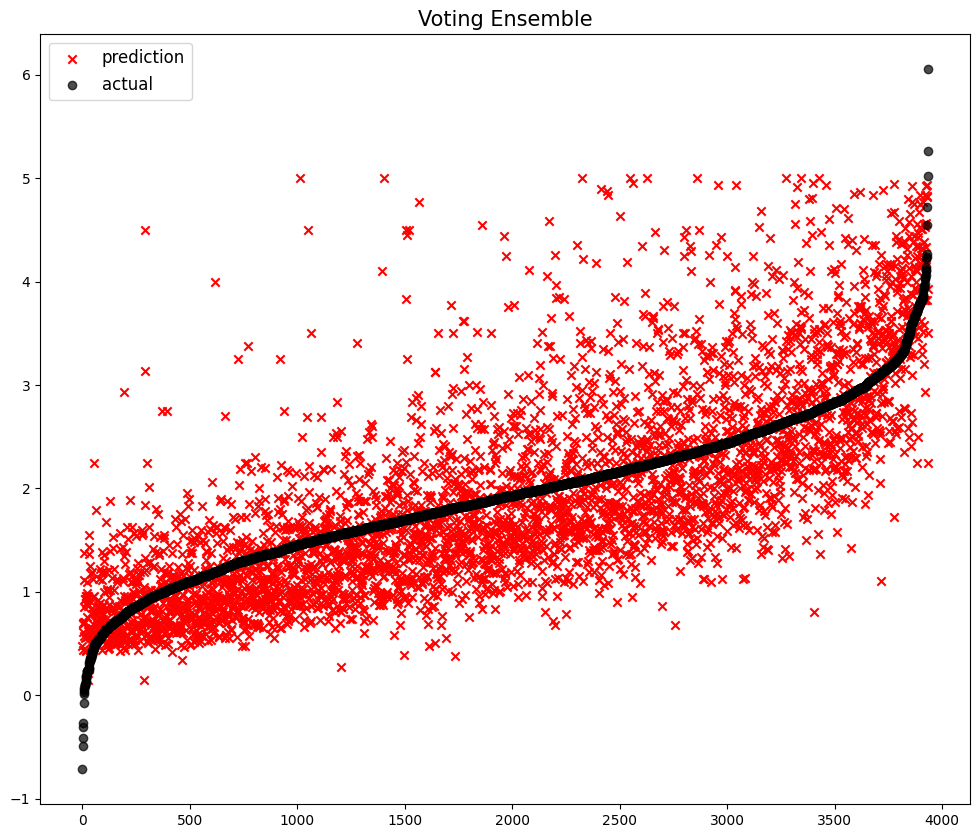

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494


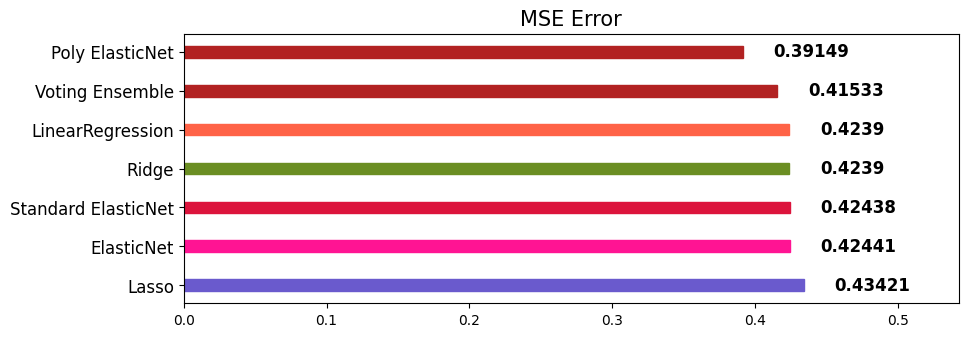

In [35]:
utils.plot_error('Voting Ensemble', voting_pred, y_test)

## 보팅 (Voting) - 분류 (Classification)

[자세한 내용 보기](https://teddylee777.github.io/machine-learning/ensemble%EA%B8%B0%EB%B2%95%EC%97%90-%EB%8C%80%ED%95%9C-%EC%9D%B4%ED%95%B4%EC%99%80-%EC%A2%85%EB%A5%98-1)

Voting 앙상블은 한 가지 **중요한 parameter**가 있습니다.   
`voting` = {'hard', 'soft'}

class를 0, 1로 분류 예측을 하는 이진 분류를 예로 들어 보겠습니다.   

### **hard** voting

**다수결의 원칙**을 따르는 방식입니다.  
각 모델이 예측한 결과(클래스) 중에서 가장 많이 선택된 클래스를 최종 결과로 채택합니다.

5개의 모델이 각각 `[1, 0, 0, 1, 1]`로 예측했다면, 1이 3표, 0이 2표를 얻었으므로 다수결에 따라 최종 예측값은 1이 됩니다.

### **soft** voting

**확률의 평균**을 따르는 방식입니다.  
각각의 확률의 평균 값을 계산한 다음에 가장 확률이 높은 클래스를 선택합니다.

Class 0이 될 확률: $(0.4, 0.9, 0.9, 0.4, 0.4)$ → 평균: 0.60  
Class 1이 될 확률: $(0.6, 0.1, 0.1, 0.6, 0.6)$ → 평균: 0.40  

- Class 0의 평균 확률이 더 높기 때문에 최종 예측값은 0이 됩니다.
- 참고: 하드 보팅에서는 1이 이겼지만, 소프트 보팅에서는 모델들이 0이라고 확신한 정도(0.9)가 컸기 때문에 결과가 뒤집힐 수 있습니다.

#### 참고) **회귀**에서의 보팅

회귀에서 Voting과 Soft Voting이 헷갈릴 수 있는데, 두 방식은 서로 다른 개념입니다.   
- Soft Voting은 각 모델이 특정 클래스라고 예측한 확률의 평균을 구함
- 회귀에서의 Voting은 모든 회귀기의 예측값을 단순 평균하에 최종 예측을 함
   
그래서 사실 Hard / Soft Voting이라는 용어도 분류에서만 쓰이는 개념인 것이죠!

In [36]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier

In [37]:
models = [
    ('Logi', LogisticRegression()),
    ('ridge', RidgeClassifier())
]

In [38]:
# voting='soft': 각 모델의 클래스 확률 평균으로 최종 예측
# SVC 등 predict_proba를 지원하지 않는 모델이 있으면 soft voting 불가
vc = VotingClassifier(models, voting='soft')

## 배깅(Bagging)

Bootstrap + Aggregating   
1. 부트스트랩을 통해 전체 데이터셋에서 중복을 허용하여 무작위로 재표본 추출을 하고,
2. 동일한 알고리즘 모델을 사용해 각각의 샘플을 독립적으로 학습하고,
3. 모든 모델의 예측값을 결합해 최종 결과를 도출하는 방법입니다.

[자세한 내용 보기](https://teddylee777.github.io/machine-learning/ensemble%EA%B8%B0%EB%B2%95%EC%97%90-%EB%8C%80%ED%95%9C-%EC%9D%B4%ED%95%B4%EC%99%80-%EC%A2%85%EB%A5%98-2)

**Voting VS Bagging**

* **Voting**이 여러 알고리즘의 조합에 대한 앙상블이라면...
* **Bagging**은 하나의 단일 알고리즘에 대하여 여러 개의 샘플 조합으로 앙상블한다는 차이가 있습니다.

### RandomForest

- DecisionTree기반 Bagging 앙상블 모델입니다.
- 사용이 쉽고, 성능도 우수해서 매우 인기가 많습니다.

In [39]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [40]:
# 랜덤 포레스트 회귀 (기본 파라미터)
# n_estimators=100 트리를 부트스트랩 샘플로 각각 학습, 평균으로 최종 예측
rfr = RandomForestRegressor(random_state=42)

rfr.fit(X_train, y_train)
rfr_pred = rfr.predict(X_test)

rfr_r2 = r2_score(y_test, rfr_pred)
rfr_mse = mean_squared_error(y_test, rfr_pred)

print(f'R2 : {round(rfr_r2, 4)}, MSE : {round(rfr_mse, 4)}')

R2 : 0.7759, MSE : 0.2235


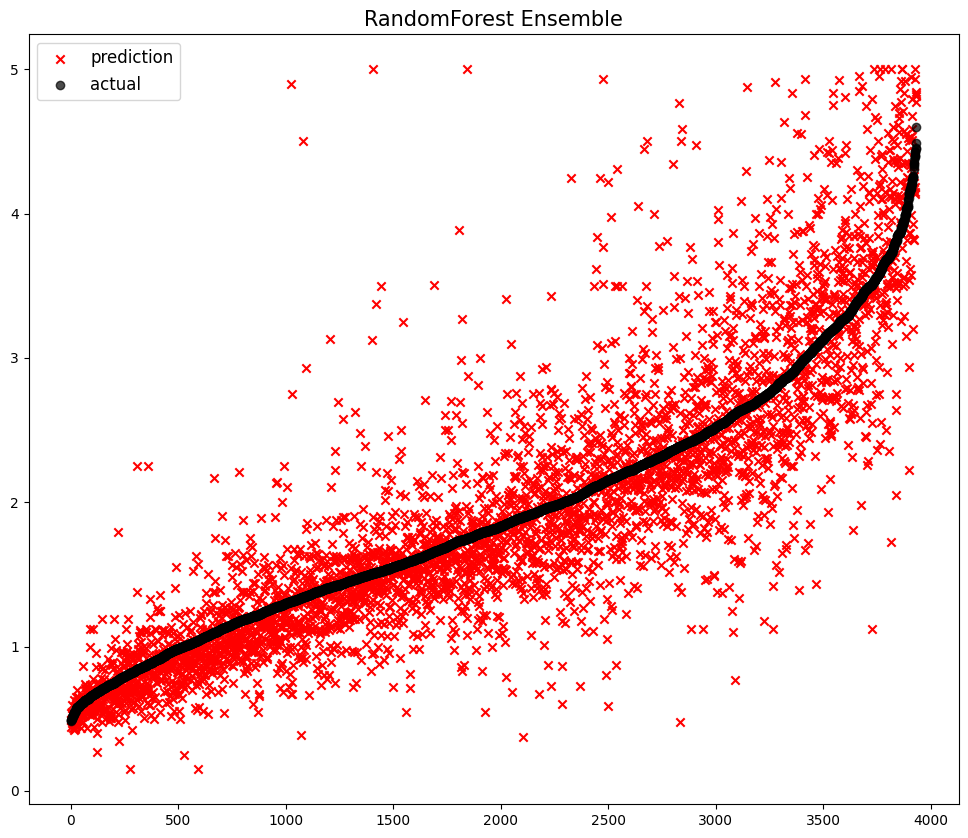

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble,0.223458


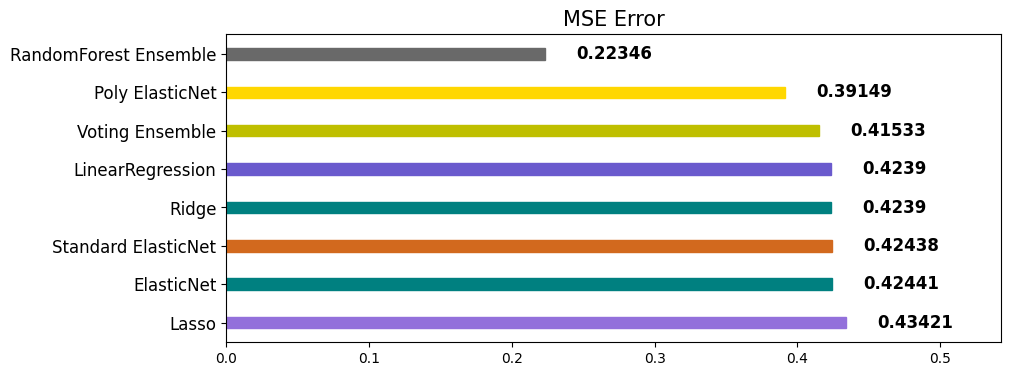

In [41]:
utils.plot_error('RandomForest Ensemble', rfr_pred, y_test)

**주요 Hyperparameter**

| 파라미터 | 설명 | 과대적합 방지 |
|----------|------|:-----------:|
| `n_estimators` | 트리 개수. 많을수록 안정적이나 느려짐 | |
| `max_depth` | 트리 최대 깊이 | ✅ |
| `max_features` | 분기 시 고려할 피처 비율 | ✅ |
| `min_samples_split` | 노드 분할 최소 샘플 수 (기본값: 2) | ✅ |
| `n_jobs` | 병렬 처리에 사용할 CPU 수 (-1 = 전체) | |
| `random_state` | 재현성을 위해 고정하고 튜닝할 것! | |


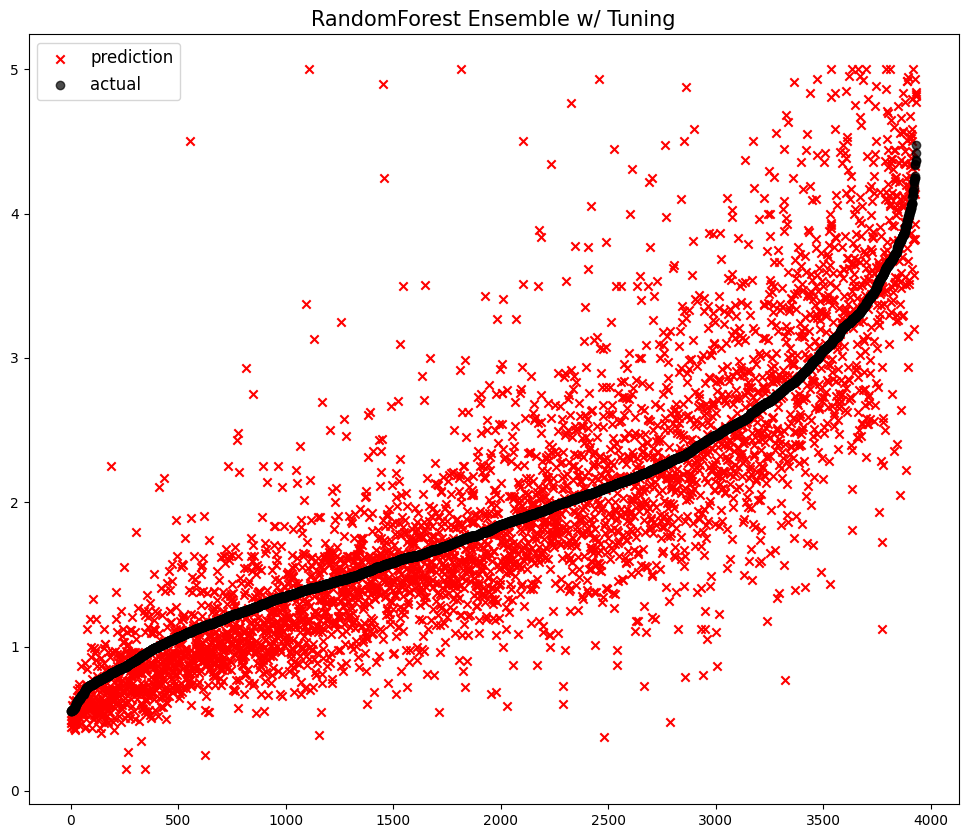

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,RandomForest Ensemble,0.223458


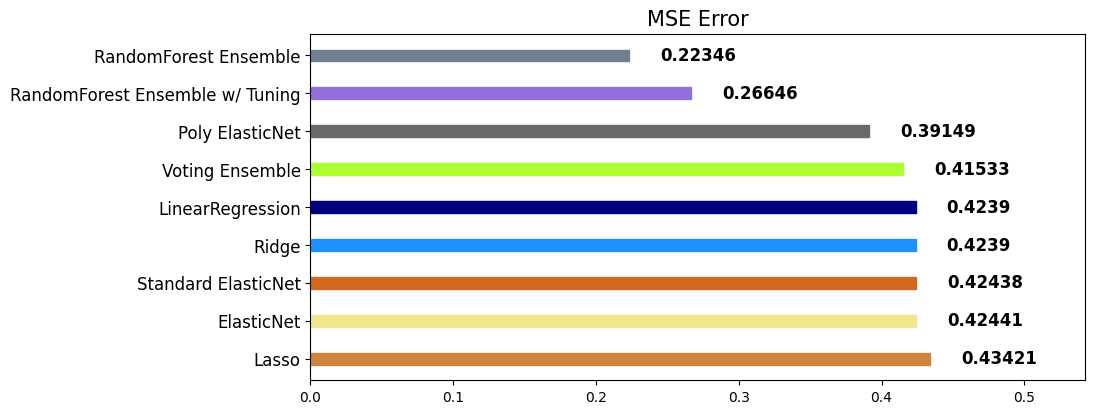

In [42]:
# 하이퍼파라미터를 직접 지정해 성능 변화를 확인
# n_estimators=1500: 트리 수 증가로 분산 감소
# max_depth=9: 트리 깊이 제한으로 과대적합 방지
# max_features=0.9: 분기 시 90% 피처만 고려

rfr = RandomForestRegressor(random_state=42, n_estimators=1500, max_depth=9, max_features=0.9)
rfr.fit(X_train, y_train)
rfr_pred = rfr.predict(X_test)
utils.plot_error('RandomForest Ensemble w/ Tuning', rfr_pred, y_test)

## 부스팅 (Boosting)

[자세한 내용 보기]('https://teddylee777.github.io/machine-learning/ensemble%EA%B8%B0%EB%B2%95%EC%97%90-%EB%8C%80%ED%95%9C-%EC%9D%B4%ED%95%B4%EC%99%80-%EC%A2%85%EB%A5%98-3')

약한 학습기를 순차적으로 학습을 하되, 이전 학습에 대하여 잘못 예측된 데이터에 **가중치를 부여해 오차를 보완**해 나가는 방식입니다.

**장점**
- 성능이 매우 우수합니다. (Lgbm, XGBoost 등)

**단점**
- 부스팅 알고리즘의 특성상 계속 약점(오분류/잔차)을 보완하려고 하기 때문에 **잘못된 레이블링이나 아웃라이어에 필요 이상으로 민감**할 수 있습니다.
- 순차적이기 때문에 병렬처리에 어려움이 있고, 그렇다보니 **학습 시간이 오래걸립니다.**.

### GradientBoost

In [43]:
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

In [44]:
# GradientBoosting 회귀 (기본 파라미터)
# 잔차(residual)를 순차적으로 학습 → 느리지만 성능 우수
gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

gbr_r2 = r2_score(y_test, gbr_pred)
gbr_mse = mean_squared_error(y_test, gbr_pred)

print(f'R2 : {round(gbr_r2, 4)}, MSE : {round(gbr_mse, 4)}')

R2 : 0.7507, MSE : 0.2486


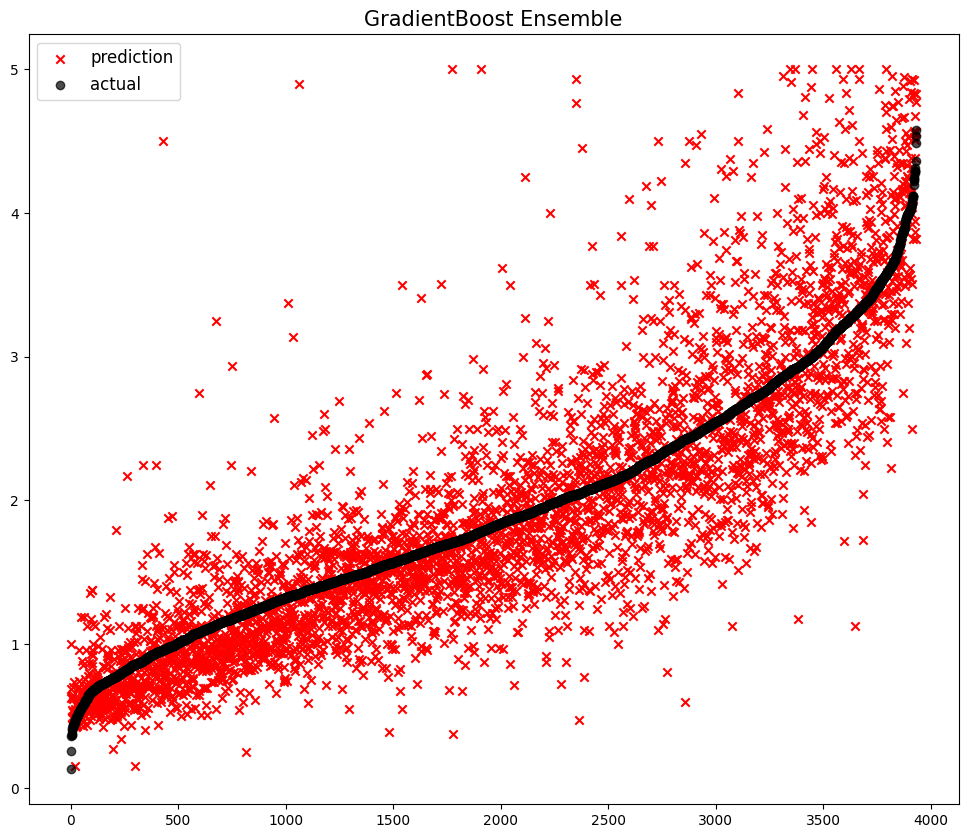

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,GradientBoost Ensemble,0.248581
9,RandomForest Ensemble,0.223458


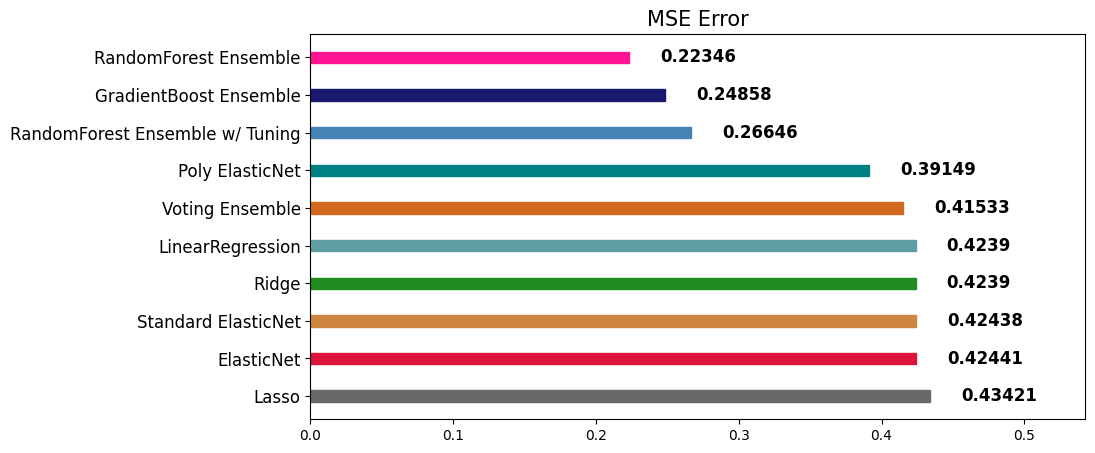

In [45]:
utils.plot_error('GradientBoost Ensemble', gbr_pred, y_test)

**주요 Hyperparameter**

| 파라미터 | 설명 | 팁 |
|----------|------|----|
| `learning_rate` | 각 트리의 기여도. 작을수록 안정적이나 `n_estimators`를 늘려야 함 | n_estimators와 함께 튜닝 |
| `n_estimators` | 부스팅 단계 수 | learning_rate와 반비례 관계 |
| `subsample` | 학습에 사용할 샘플 비율 | 과대적합 방지 |
| `min_samples_split` | 노드 분할 최소 샘플 수 | 과대적합 방지 |
| `random_state` | 재현성을 위해 반드시 고정 | |


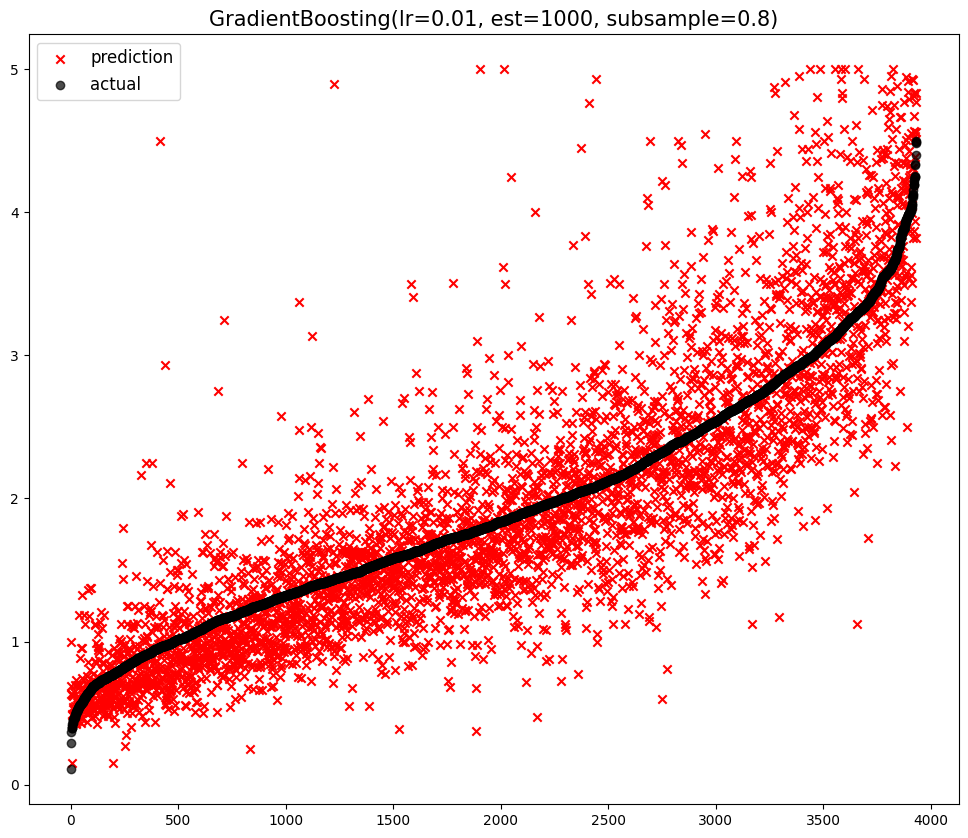

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


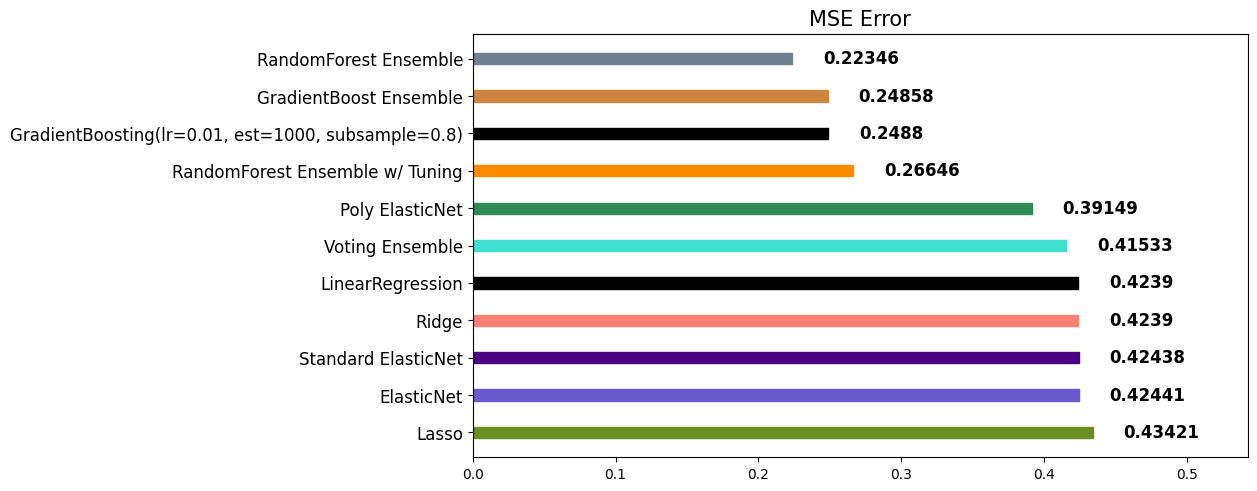

In [46]:
# 수동 튜닝: learning_rate를 낮추고 n_estimators를 늘려 더 세밀하게 학습
# subsample=0.8: 80% 샘플만 사용해 과대적합 방지
# 원하는 값들을 입력하면서 결과를 비교해보세요
gbr = GradientBoostingRegressor(random_state=42, learning_rate=0.01, n_estimators=1000, subsample=0.8)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
utils.plot_error('GradientBoosting(lr=0.01, est=1000, subsample=0.8)', gbr_pred, y_test)

### XGBoost
e**X**treme **G**radient **B**oosting

In [47]:
from xgboost import XGBRegressor, XGBClassifier

In [48]:
# XGBoost 회귀 (기본 파라미터)
# GBM 대비 병렬 처리 + L1/L2 정규화 지원 → 더 빠르고 과적합에 강함
xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)

print(f'R2 : {round(xgb_r2, 4)}, MSE : {round(xgb_mse, 4)}')

R2 : 0.8075, MSE : 0.192


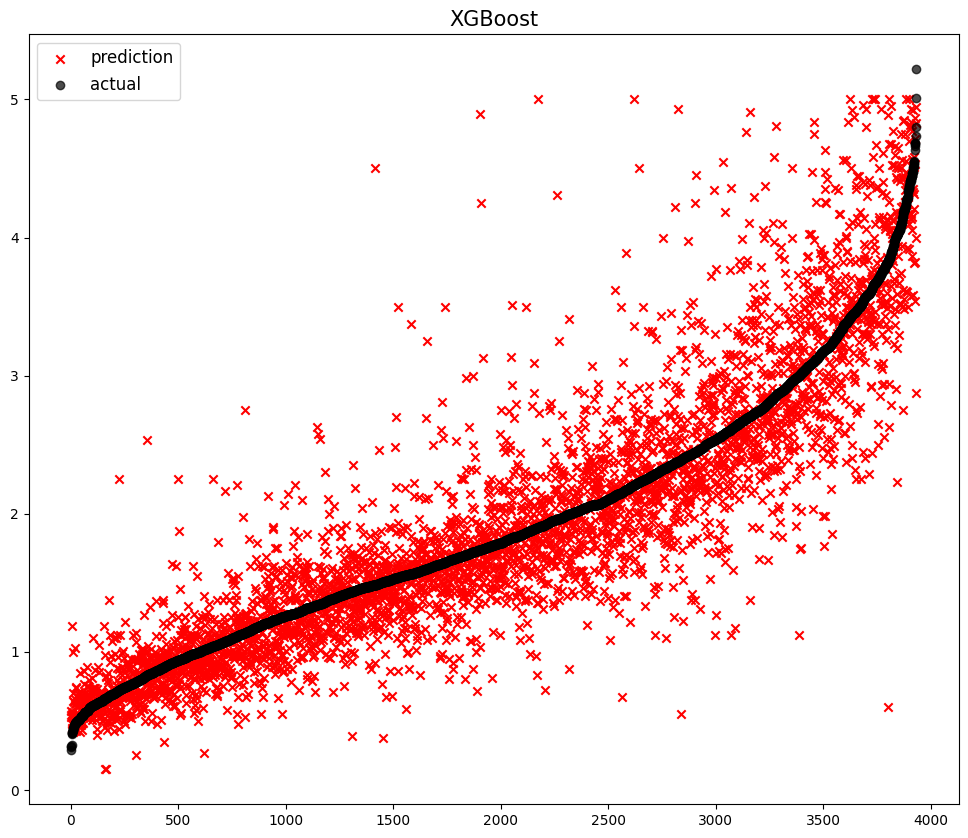

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


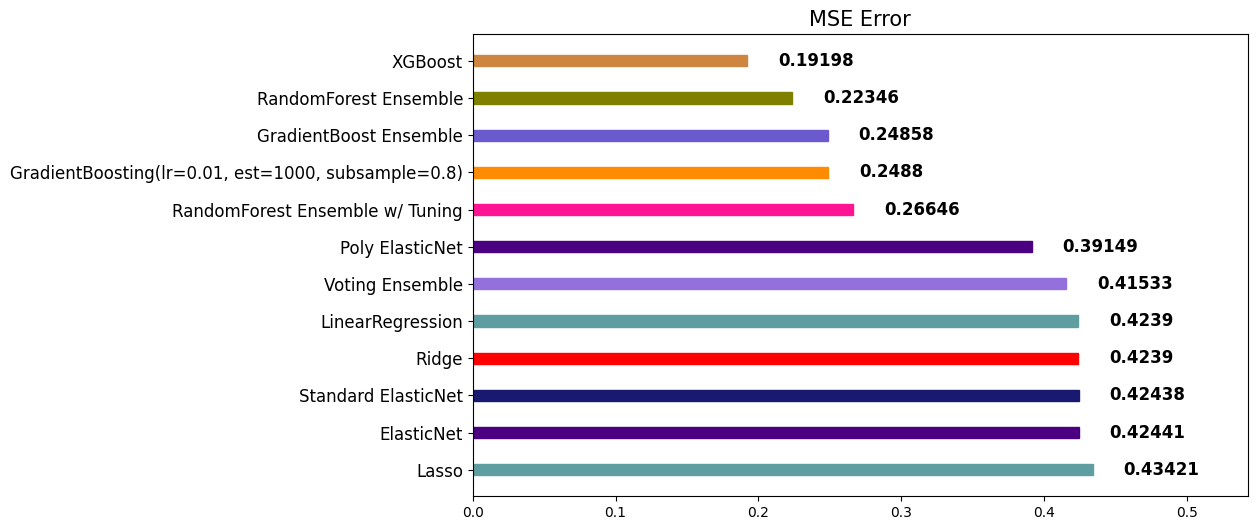

In [49]:
utils.plot_error('XGBoost', xgb_pred, y_test)

**주요 Hyperparameter**
- `random_state`: 랜덤 시드 고정 값. 고정해두고 튜닝할 것!
- `n_jobs`: CPU 사용 갯수
- `learning_rate`: 학습율. 너무 큰 학습율은 성능을 떨어뜨리고, 너무 작은 학습율은 학습이 느리다. 적절한 값을 찾아야함. n_estimators와 같이 튜닝. default=0.1
- `n_estimators`: 부스팅 스테이지 수. (랜덤포레스트 트리의 갯수 설정과 비슷한 개념). default=100
- `max_depth`: 트리의 깊이. 과대적합 방지용. default=3.
- `subsample`: 샘플 사용 비율. 과대적합 방지용. default=1.0
- `colsample_bytree`: 최대로 사용할 feature의 비율. 과대적합 방지용. default=1.0

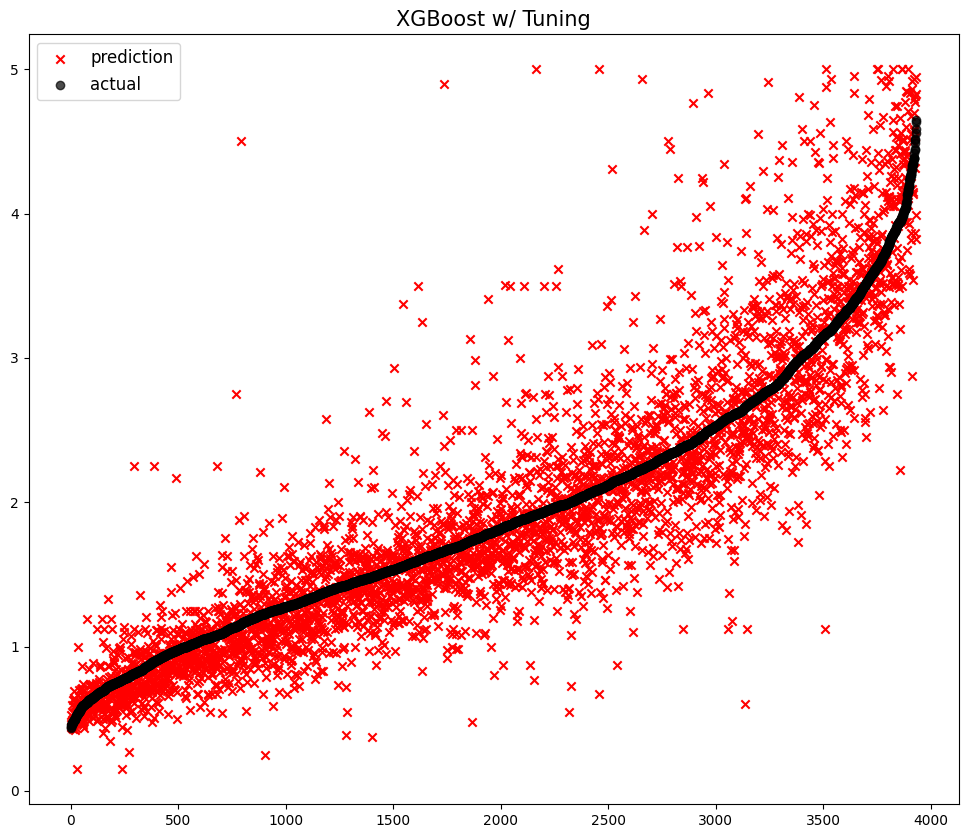

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


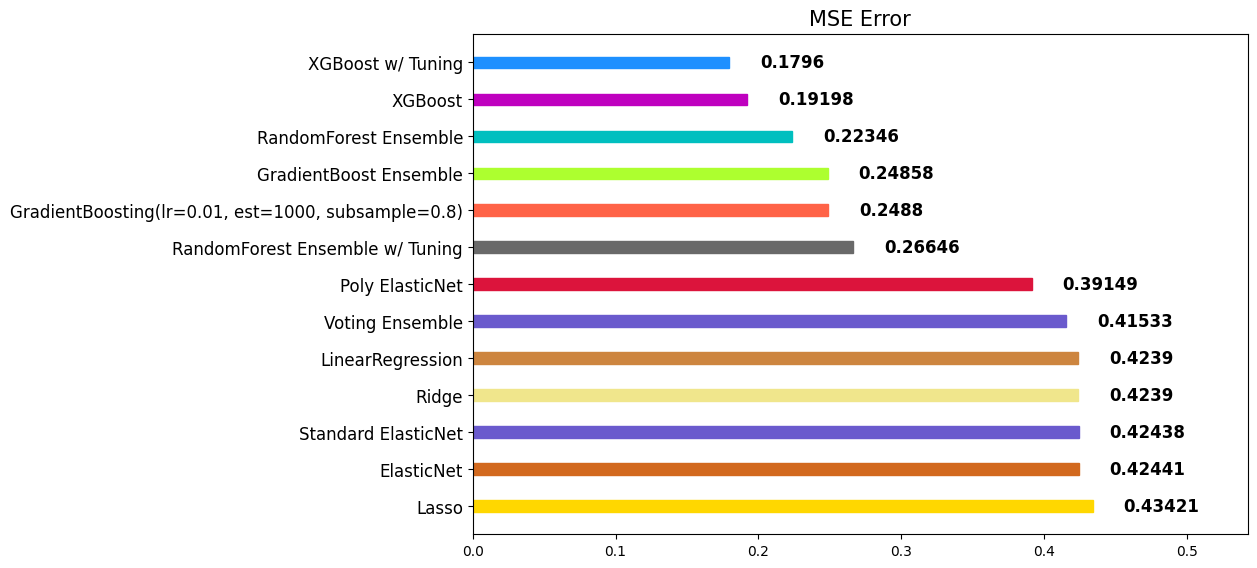

In [50]:
# 하이퍼파라미터 튜닝
xgb = XGBRegressor(random_state=42, learning_rate=0.01, n_estimators=1000, subsample=0.8, colsample_bytree=0.8, max_depth=7)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
utils.plot_error('XGBoost w/ Tuning', xgb_pred, y_test)

### LightGBM

In [51]:
from lightgbm import LGBMRegressor, LGBMClassifier

In [52]:
# LightGBM 회귀 (기본 파라미터)
# Leaf-wise 트리 성장 방식으로 GBM 계열 중 학습 속도가 가장 빠름
lgbm = LGBMRegressor(random_state=42)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

lgbm_r2 = r2_score(y_test, lgbm_pred)
lgbm_mse = mean_squared_error(y_test, lgbm_pred)

print(f'R2 : {round(lgbm_r2, 4)}, MSE : {round(lgbm_mse, 4)}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005565 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911
R2 : 0.8114, MSE : 0.188


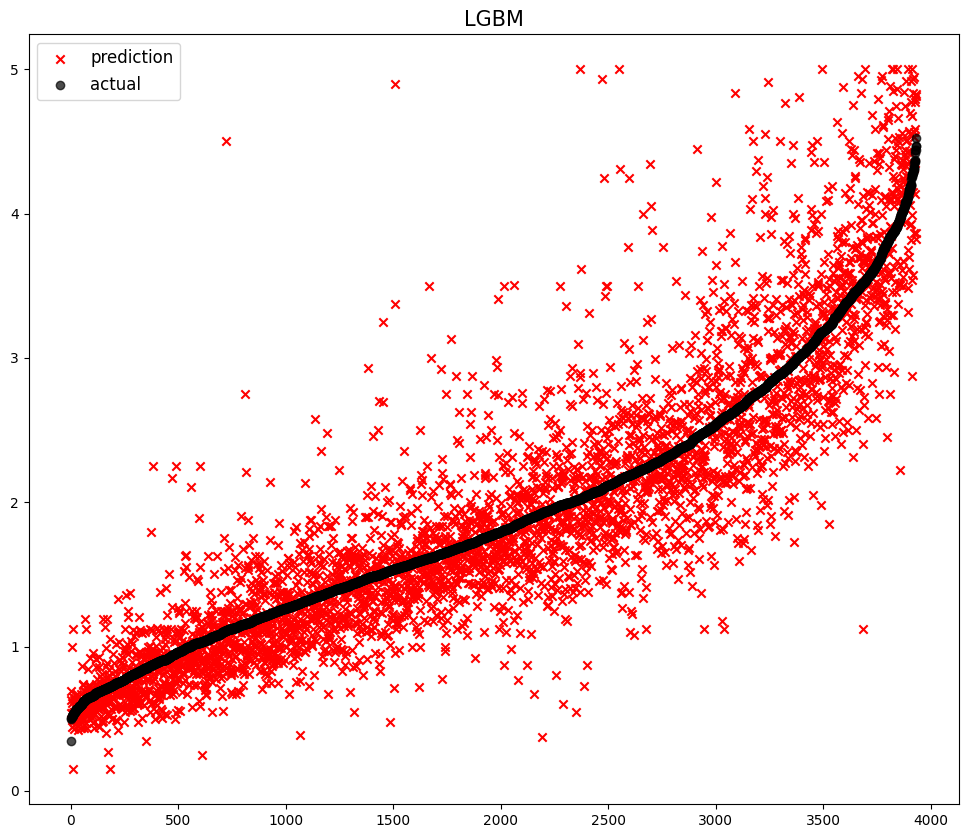

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


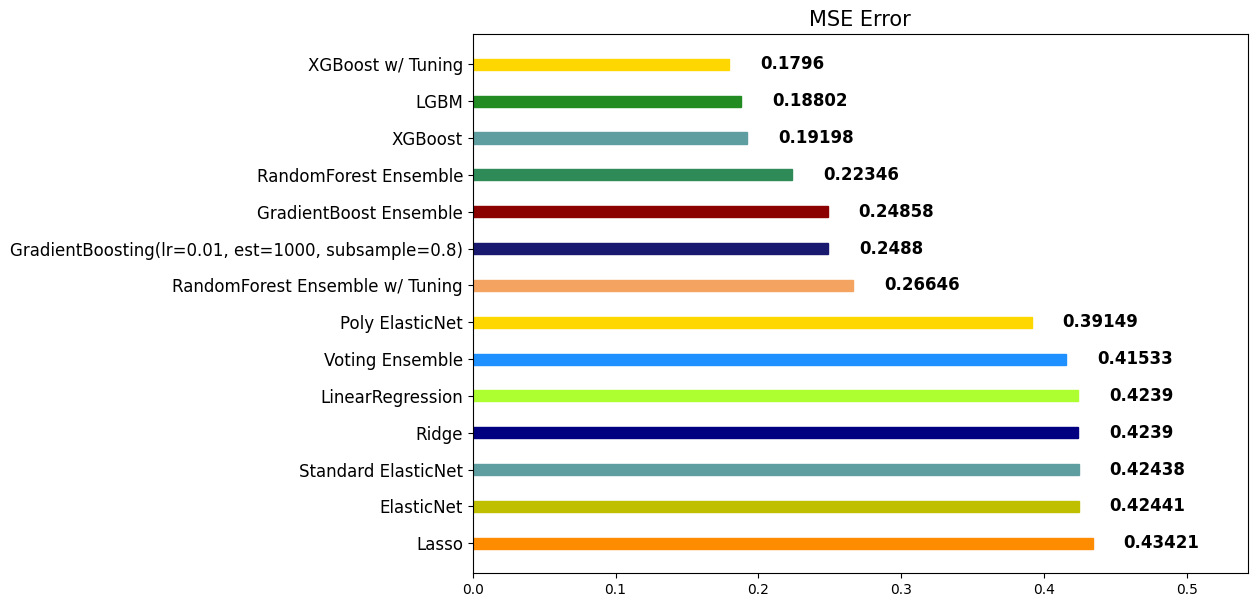

In [53]:
utils.plot_error('LGBM', lgbm_pred, y_test)

**주요 Hyperparameter**
- `random_state`: 랜덤 시드 값. 고정해두고 튜닝할 것!
- `n_jobs`: CPU 사용 개수
- `learning_rate`: 학습율. 너무 큰 학습율은 성능을 떨어뜨리고, 너무 작은 학습율은 학습이 느리다. 적절한 값을 찾아야함. n_estimators와 같이 튜닝. default=0.1
- `n_estimators`: 부스팅 스테이지 수. (랜덤포레스트 트리의 개수 설정과 비슷한 개념). default=100
- `max_depth`: 트리의 깊이. 과대적합 방지용. default=3.
- `colsample_bytree`: 샘플 사용 비율 (max_features와 비슷한 개념). 과대적합 방지용. default=1.0

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911


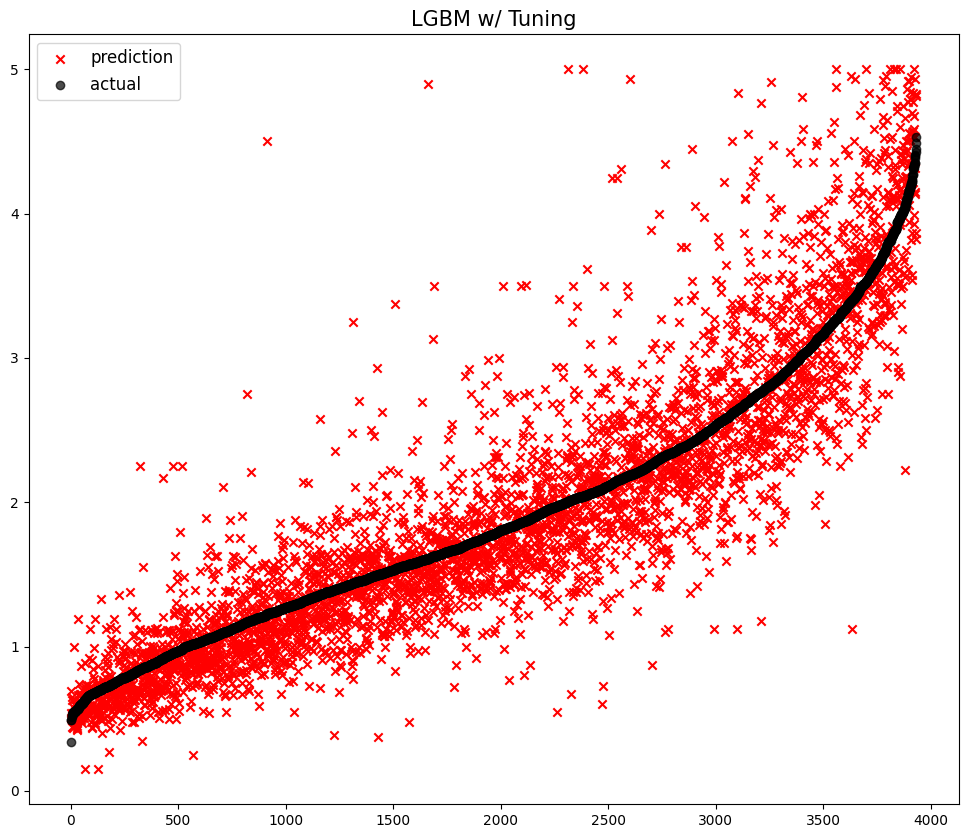

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


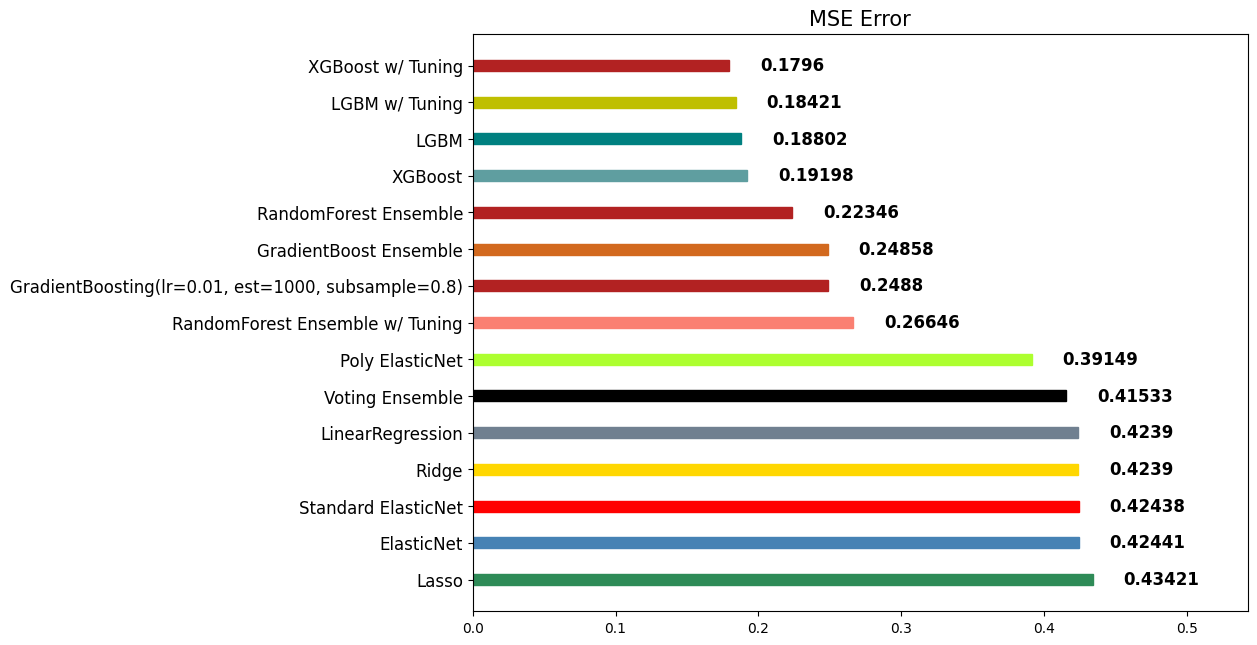

In [54]:
lgbm = LGBMRegressor(random_state=42, learning_rate=0.01, n_estimators=1000, colsample_bytree=0.9, n_jobs=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
utils.plot_error('LGBM w/ Tuning', lgbm_pred, y_test)

## Stacking

[공식문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html)

베이스 모델들의 예측값을 새로운 피처로 삼아 메타 모델이 최종 예측합니다.  
모든 앙상블 기법 중 가장 높은 성능을 낼 수 있지만, 학습 시간이 길고 과대적합 위험이 있습니다.

> `cv` 기본값(5): 각 베이스 모델을 5-fold CV로 학습해 메타 데이터를 생성합니다.  
> `n_jobs=-1`: 가능한 모든 CPU를 활용해 병렬 처리합니다.


[공식문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingRegressor.html)

In [55]:
from sklearn.ensemble import StackingRegressor

In [56]:
# 베이스 모델 목록: 서로 다른 알고리즘을 섞어 다양한 관점의 예측값을 확보
stack_models = [
    ('elasticnet', poly_pipeline),  # 선형 계열
    ('randomforest', rfr),          # 배깅 계열
    ('gbr', gbr),                   # 부스팅 계열
    ('lgbm', lgbm),                 # 부스팅 계열 (빠른 버전)
]

In [57]:
# final_estimator: 베이스 모델 예측값을 입력으로 받아 최종 예측하는 메타 모델
# Ridge를 메타 모델로 사용 → 베이스 모델 간 상관관계가 높더라도 안정적으로 결합
stack_reg = StackingRegressor(estimators=[('rfr', rfr), ('gbr', gbr), ('xgb', xgb), ('lgbm', lgbm)], final_estimator=Ridge(), n_jobs=-1)

In [58]:
# 오래 걸릴 수 있어요 (약 15분)
stack_reg.fit(X_train, y_train)
stack_pred = stack_reg.predict(X_test)

# 성능 평가
stack_r2 = r2_score(y_test, stack_pred)
stack_mse = mean_squared_error(y_test, stack_pred)

print(f'R2 : {round(stack_r2, 4)}, MSE : {round(stack_mse, 4)}')

R2 : 0.8307, MSE : 0.1689


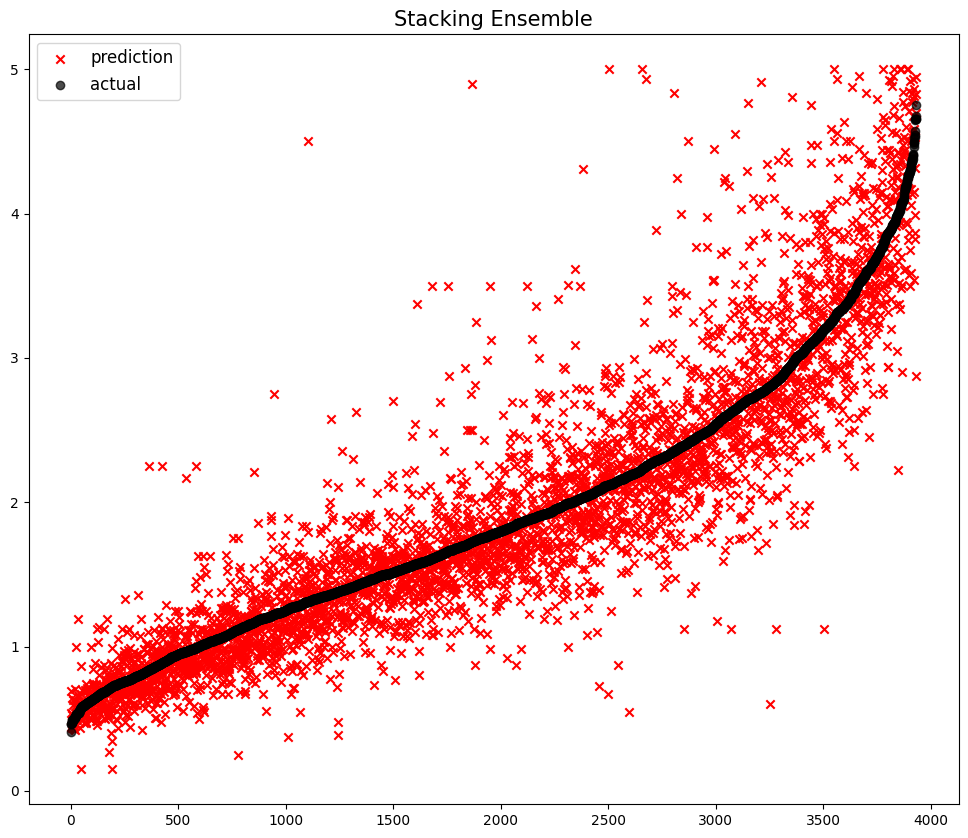

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


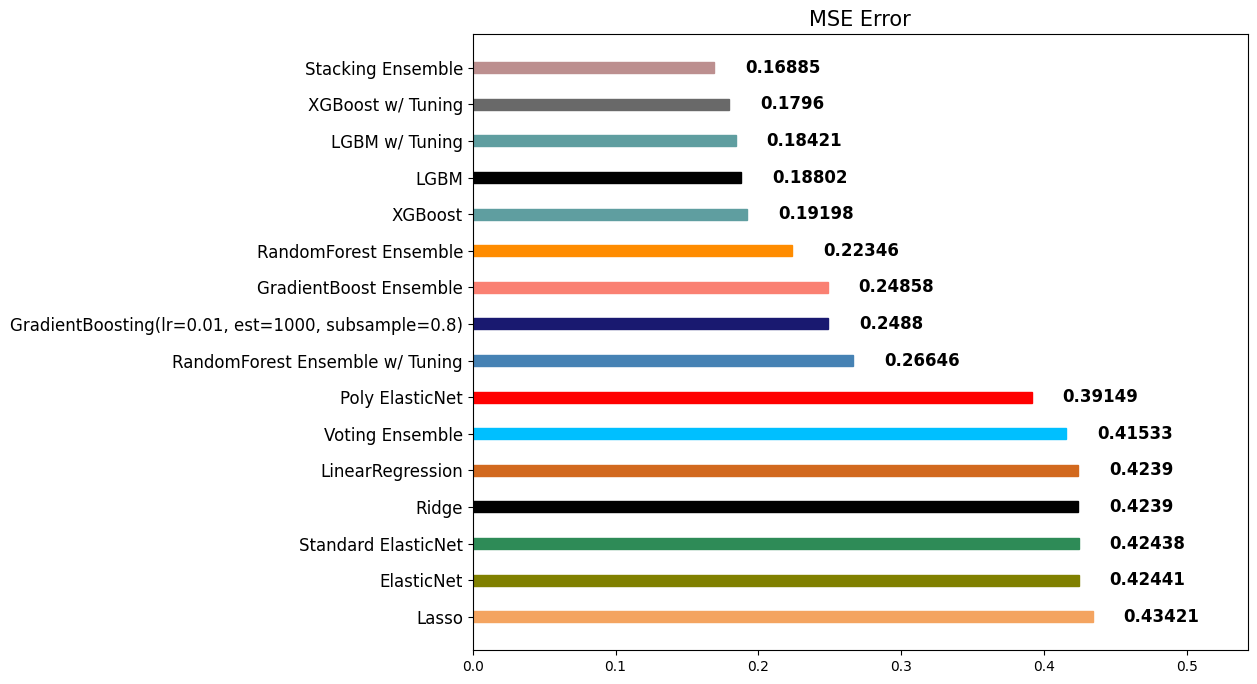

In [59]:
utils.plot_error('Stacking Ensemble', stack_pred, y_test)

# 검증 (Validation)과 튜닝 (Tuning)

## Cross Validation

단순 train/test 분할은 분할 방식에 따라 성능 평가 결과가 달라질 수 있습니다.  
**K-fold 교차검증**은 전체 데이터를 K등분하여 모든 데이터가 최소 한 번씩 테스트셋으로 사용되도록 합니다.

→ 더 신뢰할 수 있는 성능 추정치를 얻을 수 있습니다.


- Cross Validation이란 모델을 평가하는 하나의 방법입니다.
- K-겹 교차검증(K-fold Cross Validation)을 많이 활용합니다.

- **K-겹 교차검증**은 모든 데이터가 최소 한 번은 테스트셋으로 쓰이도록 합니다.

### K-Fold Cross Validation

In [60]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [61]:
n_splits = 5
kfold = KFold(n_splits=n_splits, random_state=9999, shuffle=True)

In [62]:
lgbm_fold = LGBMRegressor(random_state=42, n_jobs=-1)

In [63]:
i = 1
total_error = 0
for train_index, test_index in kfold.split(X):
    x_train_fold, x_valid_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_valid_fold = y.iloc[train_index], y.iloc[test_index]

    lgbm_pred_fold = lgbm_fold.fit(x_train_fold, y_train_fold).predict(x_valid_fold)
    error = mean_squared_error(lgbm_pred_fold, y_valid_fold)
    print('Fold = {}, prediction score = {:.2f}'.format(i, error))
    total_error += error
    i += 1

print('---' * 10)
print('Average Error: %s' % (total_error / n_splits))  # K개 폴드 MSE의 평균

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.231494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.926282
Fold = 1, prediction score = 0.19
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.930059
Fold = 2, prediction score = 0.18
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train s

## Hyperparameter 튜닝

- hypterparameter 튜닝시 경우의 수가 너무 많습니다.
- 따라서, 우리는 자동화할 필요가 있습니다.

sklearn 패키지에서 자주 사용되는 hyperparameter 튜닝을 돕는 클래스는 다음 2가지가 있습니다.

1. **RandomizedSearchCV**
2. **GridSearchCV**

**적용하는 방법**

1. 사용할 Search 방법을 선택합니다.
2. hyperparameter 도메인을 설정합니다. (`max_depth`, `n_estimators`..등등)
3. 학습을 시킨 후, 기다립니다.
4. 도출된 결과 값을 모델에 적용하고 성능을 비교합니다.

## RandomizedSearchCV

지정한 파라미터 범위에서 **무작위로 `n_iter`번 샘플링**해 최적 조합을 탐색합니다.  
GridSearchCV보다 빠르고, 파라미터 범위가 넓을 때 유리합니다.

> `n_iter`를 늘리면 더 좋은 파라미터를 찾을 가능성이 높아지지만, 그만큼 시간이 오래 걸립니다.


- 모든 매개 변수 값이 시도되는 것이 아니라 지정된 분포에서 고정된 수의 매개변수 설정이 샘플링됩니다.
- 시도된 매개 변수 설정의 수는 `n_iter`에 의해 제공됩니다.

**주요 Hyperparameter (LGBM)**
- `random_state`: 랜덤 시드 값. 고정해두고 튜닝할 것!
- `n_jobs`: CPU 사용 개수
- `learning_rate`: 학습율. 너무 큰 학습율은 성능을 떨어뜨리고, 너무 작은 학습율은 학습이 느리다. 적절한 값을 찾아야함. n_estimators와 같이 튜닝. default=0.1
- `n_estimators`: 부스팅 스테이지 수. (랜덤포레스트 트리의 개수 설정과 비슷한 개념). default=100
- `max_depth`: 트리의 깊이. 과대적합 방지용. default=3.
- `colsample_bytree`: 샘플 사용 비율 (max_features와 비슷한 개념). 과대적합 방지용. default=1.0

In [64]:
params = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.1, 0.05, 0.025],
    'max_depth': [6, 7, 8],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'subsample': [0.8, 0.9, 1.0],
}

In [65]:
from sklearn.model_selection import RandomizedSearchCV

`n_iter` 값을 조절하여, 총 몇 회의 시도를 진행할 것인지 정의합니다.

(시도가 늘어나면, 더 좋은 parameter를 찾을 확률은 올라가지만, 그만큼 시간이 오래걸립니다.)

In [66]:
# n_iter=25: 파라미터 조합 25가지를 무작위 시도
# cv=3: 각 조합을 3-fold 교차검증으로 평가
# scoring='neg_mean_squared_error': MSE 최소화 목표 (sklearn은 최대화 기준이라 음수로 반환)
clf = RandomizedSearchCV(LGBMRegressor(), params, random_state=42, cv=3, n_iter=25, n_jobs=-1, scoring='neg_mean_squared_error')

In [67]:
clf.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004668 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,estimator,LGBMRegressor()
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.1, 0.05, ...], 'max_depth': [6, 7, ...], 'n_estimators': [200, 500, ...], ...}"
,n_iter,25
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [68]:
abs(clf.best_score_)

0.17264292304557105

In [69]:
clf.best_params_

{'subsample': 0.8,
 'n_estimators': 1000,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [70]:
LGBMRegressor(**clf.best_params_)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

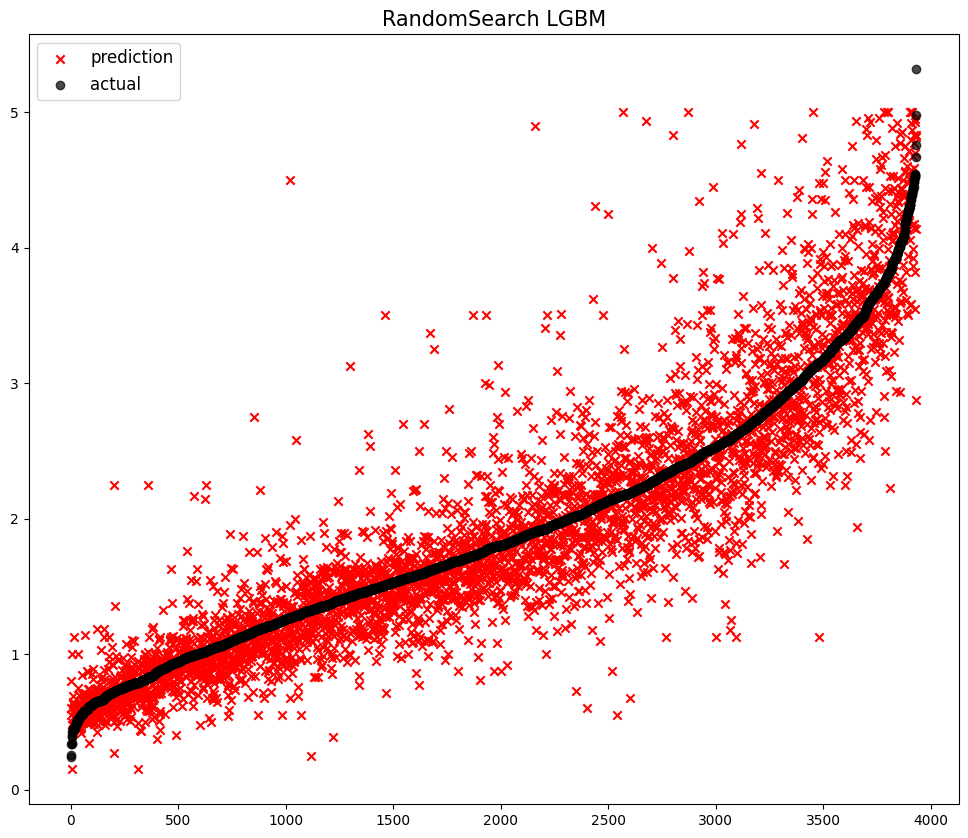

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


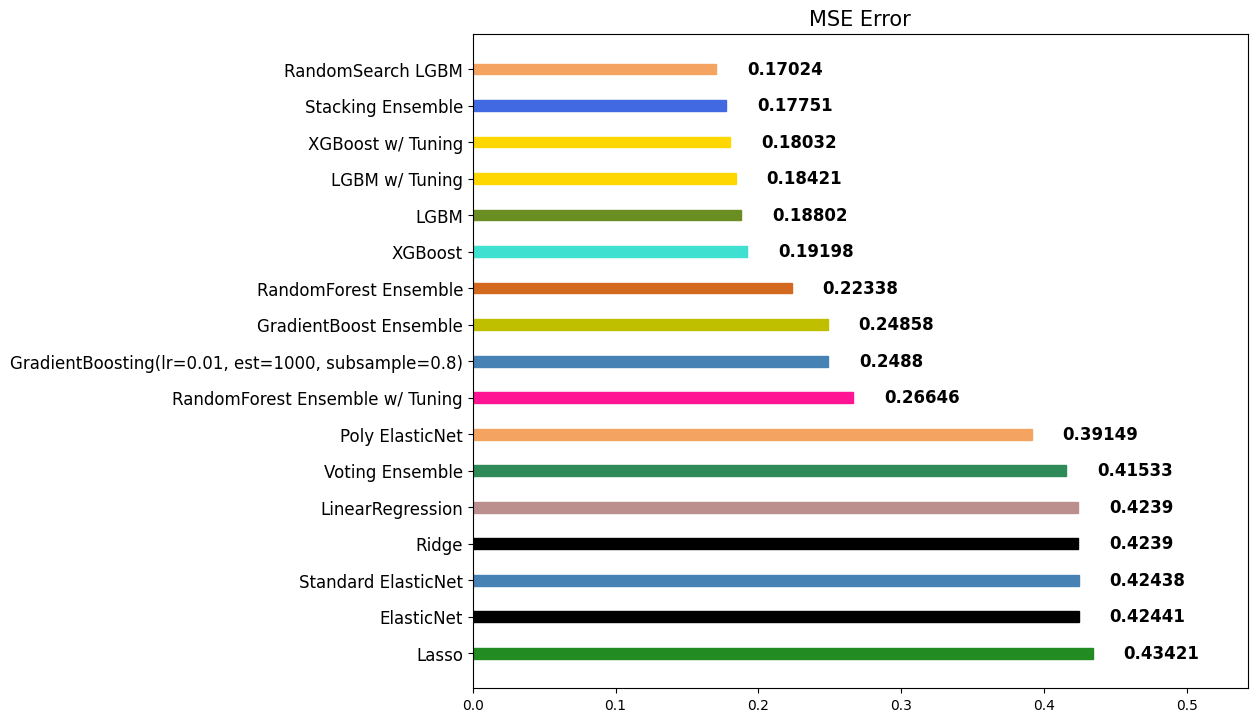

In [121]:
lgbm_best = LGBMRegressor(**clf.best_params_)
lgbm_best.fit(X_train, y_train)
lgbm_best_pred = lgbm_best.predict(X_test)
utils.plot_error('RandomSearch LGBM', lgbm_best_pred, y_test)

## GridSearchCV

지정한 파라미터 조합을 **전부 시도**하는 완전 탐색입니다.  
최적 파라미터를 반드시 찾지만, 조합 수가 많으면 시간이 매우 오래 걸립니다.

> 총 탐색 횟수 = 각 파라미터 후보 수의 곱 × cv  
> 아래 예시: 2 × 3 × 3 × 2 × 2 × 3(cv) = 216회


- 모든 매개 변수 값에 대하여 **완전 탐색**을 시도합니다.
- 따라서, 최적화할 parameter가 많다면, **시간이 매우 오래** 걸립니다.

In [71]:
params = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.1, 0.05, 0.01],
    'num_leaves': [9, 12, 15],
    'colsample_bytree': [0.8, 0.9],
    'subsample': [0.8, 0.9,],
}

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
# n_jobs=-1: 모든 CPU를 병렬로 활용해 탐색 시간 단축
grid_search = GridSearchCV(LGBMRegressor(), params, n_jobs=-1, cv=3, scoring='neg_mean_squared_error')

In [74]:
grid_search.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911


,estimator,LGBMRegressor()
,param_grid,"{'colsample_bytree': [0.8, 0.9], 'learning_rate': [0.1, 0.05, ...], 'n_estimators': [500, 1000], 'num_leaves': [9, 12, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [75]:
abs(grid_search.best_score_)

0.17374016071815324

In [76]:
grid_search.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'n_estimators': 1000,
 'num_leaves': 15,
 'subsample': 0.8}

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 8
[LightGBM] [Info] Start training from score 1.921911


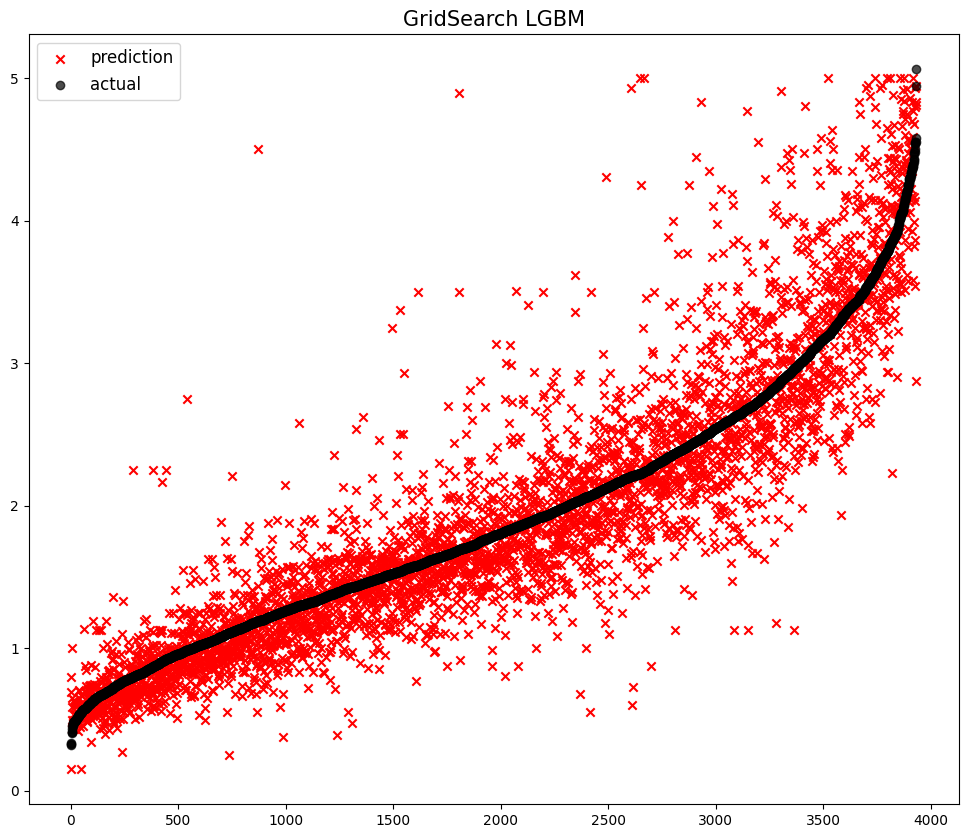

,model,error
0,Lasso,0.434209
1,ElasticNet,0.424410
2,Standard ElasticNet,0.424381
3,Ridge,0.423898
4,LinearRegression,0.423897
5,Voting Ensemble,0.415333
6,Poly ElasticNet,0.391494
7,RandomForest Ensemble w/ Tuning,0.266462
8,"GradientBoosting(lr=0.01, est=1000, subsample=...",0.248798
9,GradientBoost Ensemble,0.248581


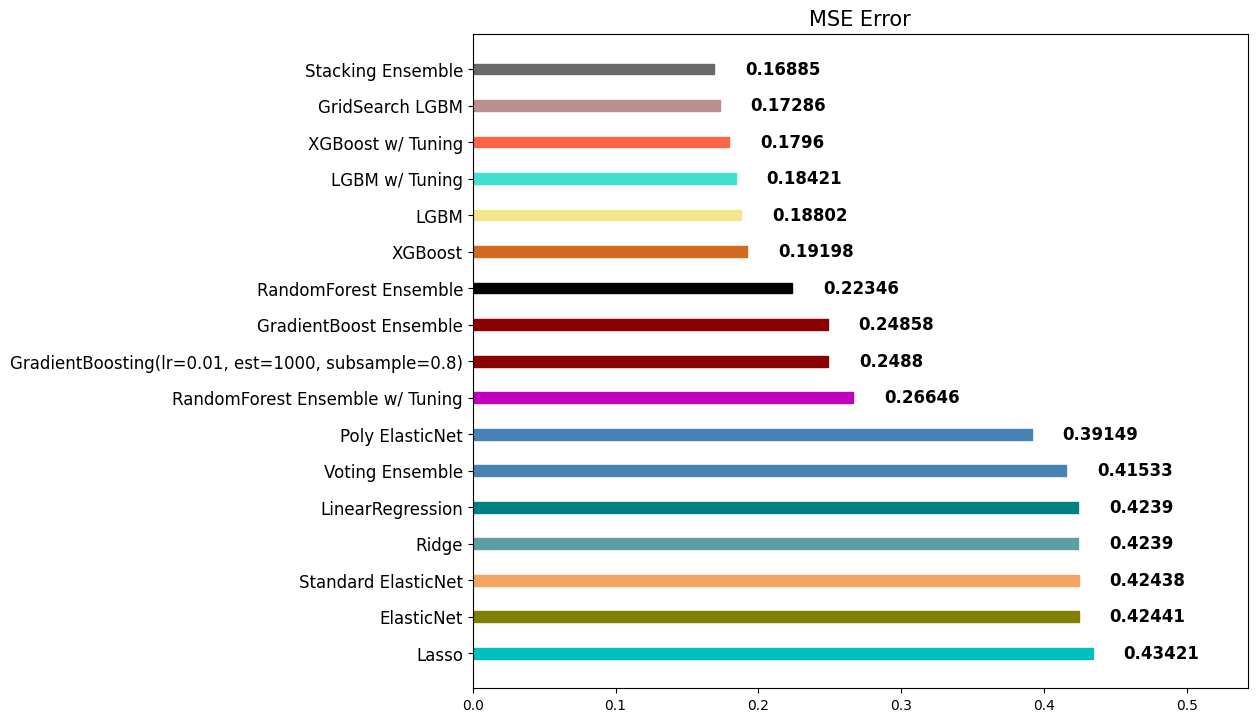

In [77]:
lgbm_best = LGBMRegressor(**grid_search.best_params_)
lgbm_best.fit(X_train, y_train)
lgbm_best_pred = lgbm_best.predict(X_test)
utils.plot_error('GridSearch LGBM', lgbm_best_pred, y_test)

---
# [과제2] 모델 성능을 높여봅시다!

이제 직접 다른 전처리 기법, 피쳐 엔지니어링, 앙상블 기법, 추가 하이퍼파라미터 튜닝 등등..을 수행해서  
아래 데이터셋을 활용해 더 높은 정확도를 가지는 모델을 만들어보세요!  
다양한 방법을 수행해보고, 비교한 후 결과를 정리해서 마크다운으로 남겨주시면 되겠습니다.   
이때 각 단계별로 어떤 방법을 수행했는지에 대한 주석을 꼼꼼히 달아주세요.  

- voting, bagging, boosting, stacking 중 어떤 모델을 사용하셔도 됩니다
- 정확도는 소수점 자릿수 제한 없이 모두 출력합니다.
- `random_state`는 모두 'SEED'로 고정해주세요.
- 모델을 출력하는 코드는 아래를 참고하세요

```python
model = #원하는 모델 넣기
model.fit(X_train, y_train)
y_model_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_model_pred)}")
```

In [78]:
# 데이터 분할 및 교차 검증
from sklearn.model_selection import cross_val_score

# 성능 평가 지표
from sklearn.metrics import accuracy_score, classification_report

# 기본 분류 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 앙상블 모델
from sklearn.ensemble import (
    VotingClassifier,           # 보팅
    BaggingClassifier,          # 배깅
    RandomForestClassifier,     # 랜덤 포레스트
    AdaBoostClassifier,         # 에이다부스트
    GradientBoostingClassifier, # 그래디언트 부스팅
    StackingClassifier          # 스태킹
)

# 외부 부스팅 라이브러리
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42

In [79]:
# ===== 데이터 준비 =====
df = pd.read_csv('Telco-Customer-Churn.csv')

target = 'Churn'
X = df.drop(columns=[target, 'customerID'])
y = df[target].map({'Yes': 1, 'No': 0})

## 데이터셋 소개: Telco Customer Churn

<a>https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download

### 데이터셋 설명
- **출처**: IBM Sample Data / Kaggle
- **문제 유형**: 이진 분류 (Binary Classification)
- **예측 목표**: 고객의 이탈 여부 예측 (Churn: Yes/No)
- **데이터 크기**: 7,043개 행, 21개 열
- **실무 활용**: 통신사, 구독 서비스 등에서 고객 이탈 방지 전략 수립에 활용

### 주요 특징
- **클래스 불균형**: 이탈 고객 약 27%, 유지 고객 약 73%
- **다양한 변수 유형**: 범주형 변수와 수치형 변수 혼합
- **실무 유사성**: 실제 비즈니스 문제와 매우 유사한 구조

### 변수 설명

#### 1. 고객 정보
- `customerID`: 고객 ID (분석에서 제외)
- `gender`: 성별 (Male/Female)
- `SeniorCitizen`: 고령자 여부 (0/1)
- `Partner`: 배우자 유무 (Yes/No)
- `Dependents`: 부양가족 유무 (Yes/No)

#### 2. 서비스 정보
- `tenure`: 서비스 이용 개월 수
- `PhoneService`: 전화 서비스 가입 여부
- `MultipleLines`: 복수 회선 여부
- `InternetService`: 인터넷 서비스 유형 (DSL/Fiber optic/No)
- `OnlineSecurity`: 온라인 보안 서비스
- `OnlineBackup`: 온라인 백업 서비스
- `DeviceProtection`: 기기 보호 서비스
- `TechSupport`: 기술 지원 서비스
- `StreamingTV`: TV 스트리밍 서비스
- `StreamingMovies`: 영화 스트리밍 서비스

#### 3. 계약 정보
- `Contract`: 계약 유형 (Month-to-month/One year/Two year)
- `PaperlessBilling`: 전자 청구서 사용 여부
- `PaymentMethod`: 결제 방법
- `MonthlyCharges`: 월 요금
- `TotalCharges`: 총 납부 금액

#### 4. 타겟 변수
- `Churn`: 이탈 여부 (Yes/No) - **예측 목표**

In [80]:
# 범주형 변수 → 숫자 인코딩 (LabelEncoder)
cat_cols = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# TotalCharges가 문자열인 경우 숫자로 변환 (공백 문자열 → NaN → 중앙값으로 대체)
if X['TotalCharges'].dtype == 'object':
    X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
    X['TotalCharges'].fillna(X['TotalCharges'].median(), inplace=True)

# MinMaxScaler로 [0, 1] 정규화
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# stratify=y: 클래스 불균형(이탈 27% / 유지 73%)을 유지하며 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

In [81]:
model = xgb.XGBClassifier(random_state=SEED) # 원하는 모델 넣기
model.fit(X_train, y_train)
y_model_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_model_pred)}")

Model Accuracy: 0.7751277683134583


마지막으로, 아래 내용을 마크다운 셀에 정리해주세요
- 1. 과제 1 실행해보며 느낀 점
- 2. 과제 2에서 사용한 모델
- 3. 과제 2 모델 튜닝할 때 사용한 방법, 그리고 그렇게 해서 찾은 하이퍼파라미터값
- 4. 튜닝한 모델로 예측한 결과 (바로 위 셀 출력 결과 복사 붙여넣기)

## 📝 과제 정리

### 1. 과제 1 실행해보며 느낀 점

우선 과제 1을 실행해 보며.. 한 학기 전에 했던 것임에도 불구하고 잘 기억이 나지 않아서 노션과 제미나이를 깔짝인 제가 부끄러웠습니다. 아무튼 그래도 더듬더듬해보니까 머신러닝 파이프라인 기초가 다시 제대로 잡히는 느낌이에요.

특히 단일 선형 모델이랑 앙상블 모델의 성능 차이를 직접 눈으로 비교하면서 앙상블 기법이 왜 실무에서 많이 쓰이는지 체감할 수 있었습니다. 또한 Pipeline을 활용해 전처리와 모델 학습을 하나의 흐름으로 연결하면 데이터 누수를 방지할 수 있다는 점도 다시 한 번 확인했습니다.

---

### 2. 과제 2에서 사용한 모델

**`XGBClassifier` (XGBoost 분류기)**

- Telco Customer Churn 데이터셋(이진 분류)에 XGBoost 분류기를 사용했습니다.
- 범주형 변수는 `LabelEncoder`로 인코딩하고, 수치형 변수는 `MinMaxScaler`로 정규화한 뒤 학습했습니다.
- 클래스 불균형(이탈 27% / 유지 73%)을 고려하여 `stratify=y` 옵션으로 데이터를 분할했습니다.

---

### 3. 과제 2 모델 튜닝할 때 사용한 방법 및 찾은 하이퍼파라미터값

**튜닝 방법: `RandomizedSearchCV`**

지정한 파라미터 범위에서 무작위로 샘플링해 최적 조합을 탐색하는 방식을 사용했습니다. `GridSearchCV` 대비 탐색 시간을 줄이면서도 넓은 탐색 공간을 커버할 수 있어 선택했습니다.

```python
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

clf = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=SEED),
    params,
    n_iter=25,
    cv=3,
    scoring='accuracy',
    random_state=SEED,
    n_jobs=-1
)
clf.fit(X_train, y_train)
```

**찾은 최적 하이퍼파라미터값:**

| 파라미터 | 값 |
|---|---|
| `n_estimators` | 300 |
| `learning_rate` | 0.05 |
| `max_depth` | 5 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |

---

### 4. 튜닝한 모델로 예측한 결과

```
Model Accuracy: 0.7751277683134583
```

수고하셨습니다!